# Evaluación visual amplia de aprendizaje de modelos dinámicos

Este notebook compara de forma **visual** y **cuantitativa** los modelos:

- `GP_DX`
- `GP_ACCEL`
- `GP_RES_ACCEL`
- `MASS` (baseline opcional)

Objetivo: analizar **qué modelo aprende mejor** usando el mismo dataset común tipo `GP_DX` (`Z=[x,y,z,vx,vy,vz,Fx,Fy,Fz]`, `dX=[Δx,Δy,Δz,Δvx,Δvy,Δvz]`).

## Qué incluye
- evaluación de **checkpoints ya entrenados**
- evaluación **justa reentrenando desde cero** sobre el mismo split
- tablas resumen y **leaderboard**
- gráficos de error por modelo y por eje
- **pred vs true**
- distribuciones de residuales
- error **open-loop** a varios horizontes
- trayectorias de ejemplo para ver acumulación de error
- curvas de aprendizaje opcionales

> Recomendación: usa primero `RUN_CHECKPOINT_EVAL=True` y `RUN_RETRAIN_EVAL=True`.  
> La comparación más justa entre arquitecturas es la de **reentrenamiento desde cero**.


In [17]:

# Celda 1 — Imports, configuración y paths

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "True")
%matplotlib inline

# ------------------------------------------------------------------
# Configuración general
# ------------------------------------------------------------------
PROJECT_DIR = os.getcwd()
LOG_DIR = os.path.join(PROJECT_DIR, "logs")
OUT_DIR = os.path.join(LOG_DIR, "evaluation_learning_notebook")
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TEST_FRAC = 0.2
HORIZONS = [1, 5, 10, 20, 50]

RUN_CHECKPOINT_EVAL = True
RUN_RETRAIN_EVAL = True
RUN_LEARNING_CURVES = True   # más lento

INCLUDE_MASS = True
CONTINUITY_TOL = 1e-4
SEED = 7

# Dataset común tipo GP_DX.
# Si existe logs/rollouts_dx_all.npz se usa automáticamente.
# Si no, ajusta aquí la ruta manualmente.
EVAL_ROLLOUTS_DX = None

# Para curvas de aprendizaje
LC_SIZES = [300, 800, 1500, 3000, 6000, 10000, 15000]
LC_DEVICE = DEVICE

# Para gráficas detalladas
SCATTER_MAX_POINTS = 4000
RESIDUAL_MAX_POINTS = 8000
ROLLOUT_EXAMPLE_HORIZON = 25
ROLLOUT_EXAMPLE_COUNT = 4
ROLLOUT_COMPONENTS = ["x", "z", "vx", "vz"]  # componentes a visualizar

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print("PROJECT_DIR:", PROJECT_DIR)
print("LOG_DIR    :", LOG_DIR)
print("OUT_DIR    :", OUT_DIR)
print("DEVICE     :", DEVICE)


PROJECT_DIR: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2
LOG_DIR    : d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs
OUT_DIR    : d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook
DEVICE     : cuda


In [5]:

# Celda 2 — Imports del evaluador y utilidades base

from evaluate_model_learning import (
    available_checkpoint_paths,
    infer_common_eval_rollouts,
    load_checkpoint_bundle,
    load_dx_rollouts,
    temporal_split_dx,
    load_checkpoint_models,
    build_model_from_type,
    evaluate_one_step_on_dx_dataset,
    rollout_open_loop_final_error,
    retrain_models_from_common_dx,
    continuity_mask_from_dx,
    preload_train_split_into_model,
    build_trainable_model,
    cfg_from_checkpoint_if_available,
)

DIM_STATE = ["x", "y", "z", "vx", "vy", "vz"]
DIM_ACC = ["ax", "ay", "az"]
DIM_POS = ["x", "y", "z"]
DIM_VEL = ["vx", "vy", "vz"]

def rows_to_df(rows):
    return pd.DataFrame(rows) if len(rows) else pd.DataFrame()

def savefig(name):
    path = os.path.join(OUT_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("Guardado:", path)

def metric_cols_for_ranking():
    return [
        "next_state_rmse_mean",
        "next_pos_rmse_mean",
        "next_vel_rmse_mean",
        "acc_rmse_mean",
    ]

def leaderboard_df(df, primary_metric="next_state_rmse_mean"):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    use_cols = [c for c in metric_cols_for_ranking() if c in df.columns]
    out = df[["model"] + use_cols].copy()
    for c in use_cols:
        out[f"rank_{c}"] = out[c].rank(method="min", ascending=True)
    rank_cols = [c for c in out.columns if c.startswith("rank_")]
    out["rank_mean"] = out[rank_cols].mean(axis=1)
    out = out.sort_values([primary_metric, "rank_mean"], ascending=[True, True]).reset_index(drop=True)
    return out

def pretty_dataset_summary(ds, split):
    return pd.DataFrame([{
        "N_total": ds.Z.shape[0],
        "N_train": split.train.Z.shape[0],
        "N_test": split.test.Z.shape[0],
        "dt": ds.dt,
        "mass": ds.mass,
        "gravity": ds.gravity,
        "input_dim": ds.Z.shape[1],
        "output_dim": ds.dX.shape[1],
    }])

def plot_table_like_heatmap(df_rank, title="Ranking por métricas"):
    if df_rank is None or len(df_rank) == 0:
        print("Sin datos para heatmap.")
        return

    rank_cols = [c for c in df_rank.columns if c.startswith("rank_")]
    data = df_rank[rank_cols].to_numpy(dtype=float)

    fig = plt.figure(figsize=(1.8 * len(rank_cols) + 2.5, 0.8 * len(df_rank) + 2.5))
    ax = plt.gca()
    im = ax.imshow(data, aspect="auto")
    ax.set_xticks(np.arange(len(rank_cols)))
    ax.set_xticklabels([c.replace("rank_", "") for c in rank_cols], rotation=25, ha="right")
    ax.set_yticks(np.arange(len(df_rank)))
    ax.set_yticklabels(df_rank["model"].tolist())
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.9, label="rank (menor es mejor)")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.0f}", ha="center", va="center")

    savefig(title.lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def plot_grouped_metric_bars(df, metrics, title):
    if df is None or len(df) == 0:
        print("Sin datos para barras.")
        return

    x = np.arange(len(df))
    width = 0.8 / max(1, len(metrics))
    fig = plt.figure(figsize=(11, 5))
    for i, metric in enumerate(metrics):
        if metric not in df.columns:
            continue
        plt.bar(x + (i - (len(metrics)-1)/2) * width, df[metric].to_numpy(), width=width, label=metric)

    plt.xticks(x, df["model"].tolist(), rotation=20)
    plt.ylabel("error")
    plt.title(title)
    plt.legend()
    savefig(title.lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def plot_open_loop_curves(df_rollout, title):
    if df_rollout is None or len(df_rollout) == 0:
        print("Sin datos open-loop.")
        return

    fig = plt.figure(figsize=(10, 5))
    for model in sorted(df_rollout["model"].unique()):
        sub = df_rollout[df_rollout["model"] == model].sort_values("horizon")
        plt.plot(sub["horizon"], sub["final_state_rmse"], marker="o", label=model)

    plt.xlabel("Horizonte")
    plt.ylabel("RMSE estado final")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    savefig(title.lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def plot_metric_by_axis(df, prefix, dims, title):
    if df is None or len(df) == 0:
        print("Sin datos por eje.")
        return

    fig, axes = plt.subplots(1, len(dims), figsize=(5 * len(dims), 4))
    axes = np.atleast_1d(axes)
    x = np.arange(len(df))

    for j, dim in enumerate(dims):
        col = f"{prefix}_{dim}"
        if col not in df.columns:
            axes[j].axis("off")
            continue
        axes[j].bar(x, df[col].to_numpy())
        axes[j].set_xticks(x)
        axes[j].set_xticklabels(df["model"].tolist(), rotation=20)
        axes[j].set_title(col)
        axes[j].set_ylabel("error")

    fig.suptitle(title)
    savefig(title.lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def subsample_xy(y_true, y_pred, max_points=4000, seed=7):
    n = len(y_true)
    if n <= max_points:
        return y_true, y_pred
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=max_points, replace=False)
    return y_true[idx], y_pred[idx]

def plot_pred_vs_true_grid(y_true, y_pred, dims, title, max_points=4000):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_dim = y_true.shape[1]
    ncols = 3
    nrows = int(math.ceil(n_dim / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.atleast_2d(axes)

    for d in range(nrows * ncols):
        ax = axes[d // ncols, d % ncols]
        if d >= n_dim:
            ax.axis("off")
            continue

        yt, yp = subsample_xy(y_true[:, d], y_pred[:, d], max_points=max_points, seed=SEED)
        ax.scatter(yt, yp, s=8, alpha=0.35)
        lo = float(min(yt.min(), yp.min()))
        hi = float(max(yt.max(), yp.max()))
        ax.plot([lo, hi], [lo, hi], "--")
        ax.set_xlabel("true")
        ax.set_ylabel("pred")
        ax.set_title(dims[d])

    fig.suptitle(title)
    savefig(title.lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def plot_residual_boxplots(details_map, kind="next_state", title="Distribución de residuales"):
    if not details_map:
        print("Sin detalles para residuales.")
        return

    if kind == "next_state":
        dims = DIM_STATE
        key_t, key_p = "X_next_true", "X_next_pred"
    elif kind == "acc":
        dims = DIM_ACC
        key_t, key_p = "A_true", "A_pred"
    else:
        raise ValueError(kind)

    ncols = len(dims)
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 4))
    axes = np.atleast_1d(axes)

    for d, dim in enumerate(dims):
        per_model = []
        labels = []
        for model_name, pred in details_map.items():
            resid = pred[key_t][:, d] - pred[key_p][:, d]
            if len(resid) > RESIDUAL_MAX_POINTS:
                idx = np.random.default_rng(SEED).choice(len(resid), size=RESIDUAL_MAX_POINTS, replace=False)
                resid = resid[idx]
            per_model.append(resid)
            labels.append(model_name)

        axes[d].boxplot(per_model, tick_labels=labels, showfliers=False)
        axes[d].tick_params(axis='x', rotation=25)
        axes[d].set_title(dim)
        axes[d].set_ylabel("true - pred")

    fig.suptitle(title + f" ({kind})")
    savefig((title + "_" + kind).lower().replace(" ", "_").replace("—", "-") + ".png")
    plt.show()

def rollout_window_prediction(model, model_type, ds, start_idx, horizon, device):
    x_true = [ds.X[start_idx].copy()]
    x_pred = [ds.X[start_idx].copy()]

    pos_pred = ds.X[start_idx, 0:3][None, :].copy()
    vel_pred = ds.X[start_idx, 3:6][None, :].copy()

    for k in range(horizon):
        Fk = ds.F[start_idx + k:start_idx + k + 1]
        pos_pred, vel_pred = evaluate_predict_next_state_batch(model, model_type, pos_pred, vel_pred, Fk, device)
        x_pred.append(np.concatenate([pos_pred[0], vel_pred[0]], axis=0))
        x_true.append(ds.X[start_idx + k + 1].copy())

    return np.stack(x_true), np.stack(x_pred)

# Wrapper usando la misma lógica del script base
from evaluate_model_learning import predict_next_state_batch as evaluate_predict_next_state_batch

def valid_rollout_starts(ds, horizon, tol=1e-4):
    cont = continuity_mask_from_dx(ds, tol=tol)
    valid = []
    for i in range(0, max(0, len(ds.Z) - horizon)):
        if horizon == 1 or np.all(cont[i:i + horizon - 1]):
            valid.append(i)
    return valid

def plot_rollout_examples(models_map, source_name, ds, horizon=25, n_examples=4, components=("x","z","vx","vz"), tol=1e-4):
    if not models_map:
        print("No hay modelos para rollout examples.")
        return

    valid = valid_rollout_starts(ds, horizon=horizon, tol=tol)
    if len(valid) == 0:
        print("No hay ventanas continuas suficientes.")
        return

    rng = np.random.default_rng(SEED)
    starts = valid if len(valid) <= n_examples else rng.choice(valid, size=n_examples, replace=False)
    comp_idx = [DIM_STATE.index(c) for c in components]

    nrows = len(components)
    ncols = len(starts)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)

    for col, start in enumerate(starts):
        t = np.arange(horizon + 1)
        x0_true = None
        for model_name, model in models_map.items():
            xt, xp = rollout_window_prediction(model, model_name, ds, int(start), horizon, DEVICE)
            if x0_true is None:
                x0_true = xt
            for row, idx in enumerate(comp_idx):
                ax = axes[row, col]
                if model_name == list(models_map.keys())[0]:
                    ax.plot(t, x0_true[:, idx], linewidth=2, label="true")
                ax.plot(t, xp[:, idx], label=model_name)
                if row == 0:
                    ax.set_title(f"start={int(start)}")
                if col == 0:
                    ax.set_ylabel(components[row])

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)))
    fig.suptitle(f"Ejemplos open-loop ({source_name})")
    savefig(f"ejemplos_open_loop_{source_name}.png")
    plt.show()

def plot_force_vs_acc(details_map, ds_test, title):
    if not details_map:
        print("Sin detalles para F vs acc.")
        return

    F = ds_test.F
    A_true = ds_test.A
    fig, axes = plt.subplots(3, len(details_map), figsize=(4.5*len(details_map), 11), squeeze=False)

    for col, (model_name, pred) in enumerate(details_map.items()):
        A_pred = pred["A_pred"]
        for row, axis_name in enumerate(["x", "y", "z"]):
            ax = axes[row, col]
            ax.scatter(F[:, row], A_true[:, row], s=6, alpha=0.20, label="true")
            ax.scatter(F[:, row], A_pred[:, row], s=6, alpha=0.20, label="pred")
            if row == 0:
                ax.set_title(model_name)
            if col == 0:
                ax.set_ylabel(f"a{axis_name}")
            ax.set_xlabel(f"F{axis_name}")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)
    fig.suptitle(title)
    savefig(title.lower().replace(" ", "_") + ".png")
    plt.show()


In [6]:

# Celda 3 — Descubrir archivos, cargar dataset común y hacer split temporal

checkpoint_paths = available_checkpoint_paths(LOG_DIR)
eval_rollouts_path = infer_common_eval_rollouts(LOG_DIR, EVAL_ROLLOUTS_DX)

display(Markdown("## Archivos encontrados"))
print("Checkpoints encontrados:")
for k, v in checkpoint_paths.items():
    print(f"  {k:>12s}: {v}")

print("\nDataset común:", eval_rollouts_path)

if eval_rollouts_path is None:
    raise FileNotFoundError(
        "No encontré un dataset común tipo GP_DX. Guarda logs/rollouts_dx_all.npz "
        "o ajusta EVAL_ROLLOUTS_DX en la celda de configuración."
    )

if "GP_DX" in checkpoint_paths:
    bundle_ref = load_checkpoint_bundle(checkpoint_paths["GP_DX"])
elif checkpoint_paths:
    bundle_ref = load_checkpoint_bundle(next(iter(checkpoint_paths.values())))
else:
    raise FileNotFoundError(
        "No encontré checkpoints GP. Necesito al menos uno para inferir dt/mass/gravity."
    )

dt = float(bundle_ref["dt"])
mass = float(bundle_ref["mass"])
gravity = float(bundle_ref.get("g", 9.81))

ds_all = load_dx_rollouts(eval_rollouts_path, dt=dt, mass=mass, gravity=gravity)
split = temporal_split_dx(ds_all, test_frac=TEST_FRAC)

display(Markdown("## Resumen del dataset"))
display(pretty_dataset_summary(ds_all, split))


## Archivos encontrados

Checkpoints encontrados:
         GP_DX: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\svgp_dyn_dx.pt
      GP_ACCEL: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\svgp_dyn_accel.pt
  GP_RES_ACCEL: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\svgp_dyn_res_accel.pt

Dataset común: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\rollouts_dx_all.npz


## Resumen del dataset

,N_total,N_train,N_test,dt,mass,gravity,input_dim,output_dim
0,7000,5600,1400,0.01,0.393572,9.81,9,6


In [7]:

# Celda 4 — Evaluación de checkpoints ya entrenados

checkpoint_models = {}
checkpoint_rows = []
checkpoint_rollout_rows = []
checkpoint_details = {}

if RUN_CHECKPOINT_EVAL:
    checkpoint_models = load_checkpoint_models(checkpoint_paths, device=DEVICE)
    if INCLUDE_MASS:
        checkpoint_models["MASS"] = build_model_from_type(
            "MASS",
            dt=dt,
            mass=mass,
            gravity=gravity,
            device=DEVICE,
            dtype=torch.float32,
        )

    for model_name, model in checkpoint_models.items():
        out = evaluate_one_step_on_dx_dataset(model, model_name, split.test, device=DEVICE)
        checkpoint_rows.append({"model": model_name, **out["metrics"]})
        checkpoint_details[model_name] = out["pred"]

        rollout_rows = rollout_open_loop_final_error(
            model,
            model_name,
            split.test,
            horizons=HORIZONS,
            device=DEVICE,
            continuity_tol=CONTINUITY_TOL,
        )
        for rr in rollout_rows:
            checkpoint_rollout_rows.append({"model": model_name, **rr})

checkpoint_df = rows_to_df(checkpoint_rows)
checkpoint_rollout_df = rows_to_df(checkpoint_rollout_rows)

display(Markdown("## Checkpoint eval — leaderboard"))
display(leaderboard_df(checkpoint_df))


## Checkpoint eval — leaderboard

,model,next_state_rmse_mean,next_pos_rmse_mean,next_vel_rmse_mean,acc_rmse_mean,rank_next_state_rmse_mean,rank_next_pos_rmse_mean,rank_next_vel_rmse_mean,rank_acc_rmse_mean,rank_mean
0,GP_DX,0.009808,0.001029,0.018586,3.566410,1.0,4.0,1.0,4.0,2.50
1,GP_ACCEL,0.011535,0.000218,0.022852,2.285220,2.0,2.0,2.0,1.0,1.75
2,GP_RES_ACCEL,0.011591,0.000218,0.022963,2.296338,3.0,2.0,3.0,2.0,2.50
3,MASS,0.013923,0.000170,0.027677,2.767662,4.0,1.0,4.0,3.0,3.00


### Métricas one-step

,model,next_state_rmse_mean,next_pos_rmse_mean,next_vel_rmse_mean,acc_rmse_mean
0,GP_DX,0.009808,0.001029,0.018586,3.566410
1,GP_ACCEL,0.011535,0.000218,0.022852,2.285220
2,GP_RES_ACCEL,0.011591,0.000218,0.022963,2.296338
3,MASS,0.013923,0.000170,0.027677,2.767662


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_eval_-_barras_resumen.png


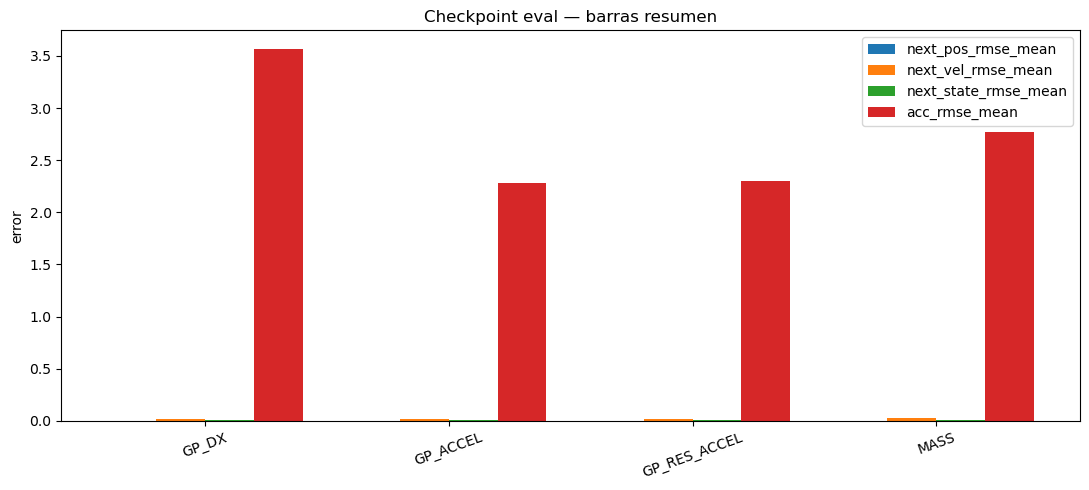

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_eval_-_ranking_por_métricas.png


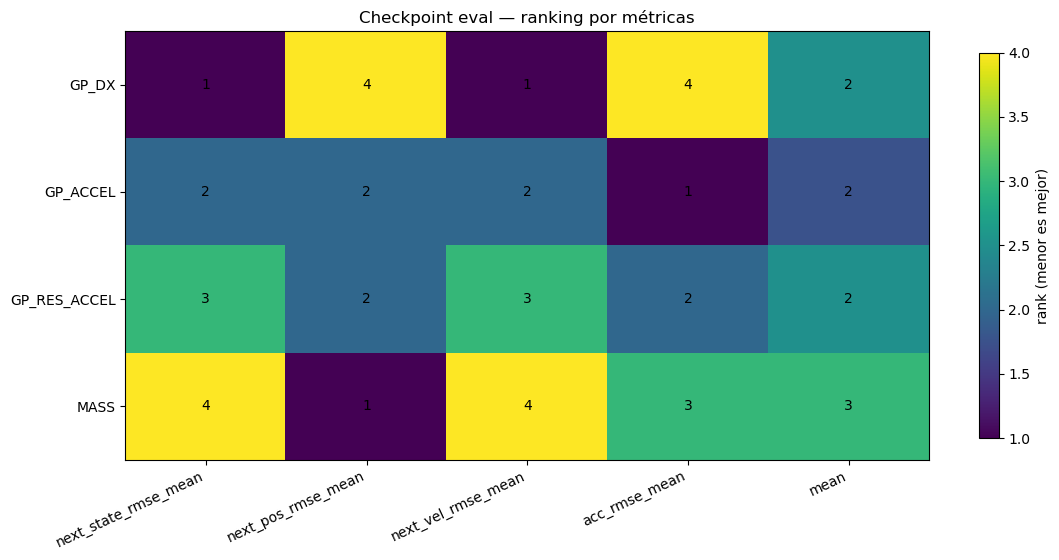

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_eval_-_error_open-loop_vs_horizonte.png


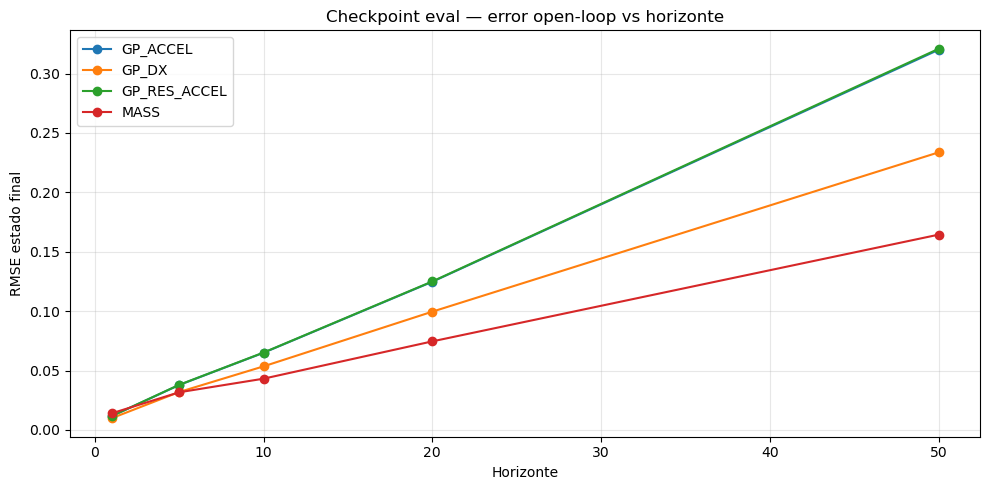

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_eval_-_rmse_por_componente_de_estado.png


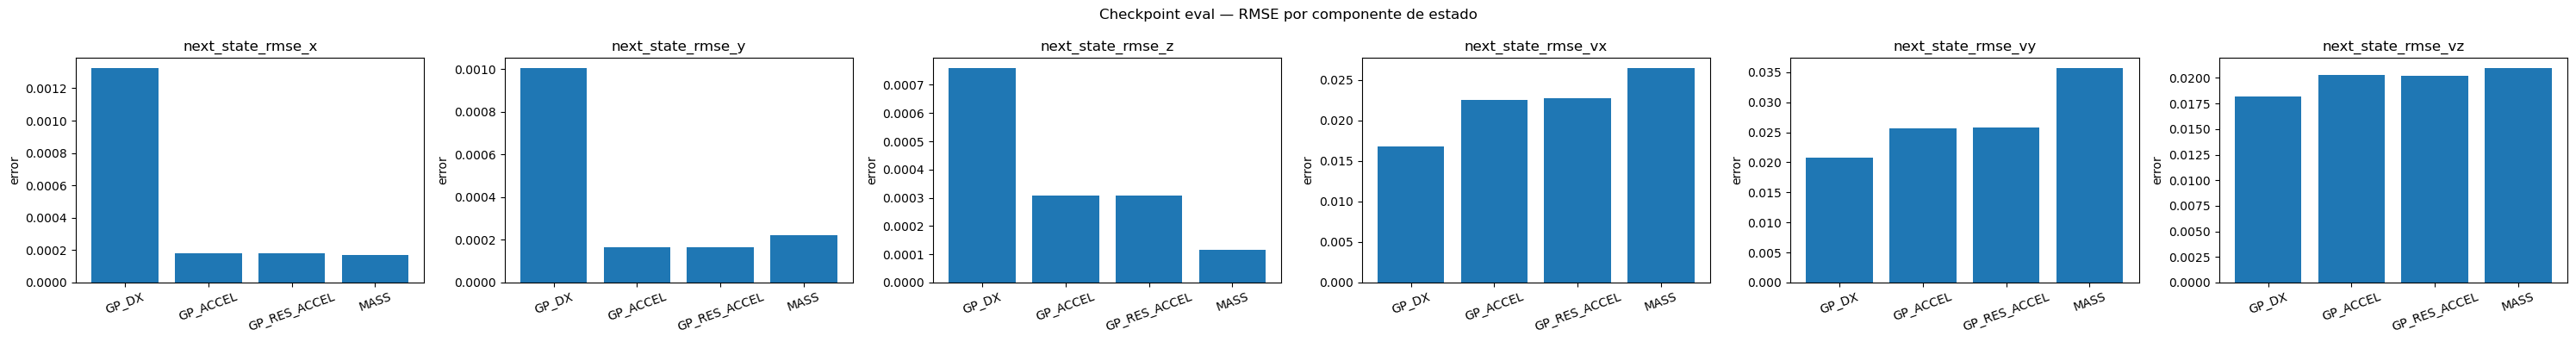

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_eval_-_rmse_por_componente_de_aceleración.png


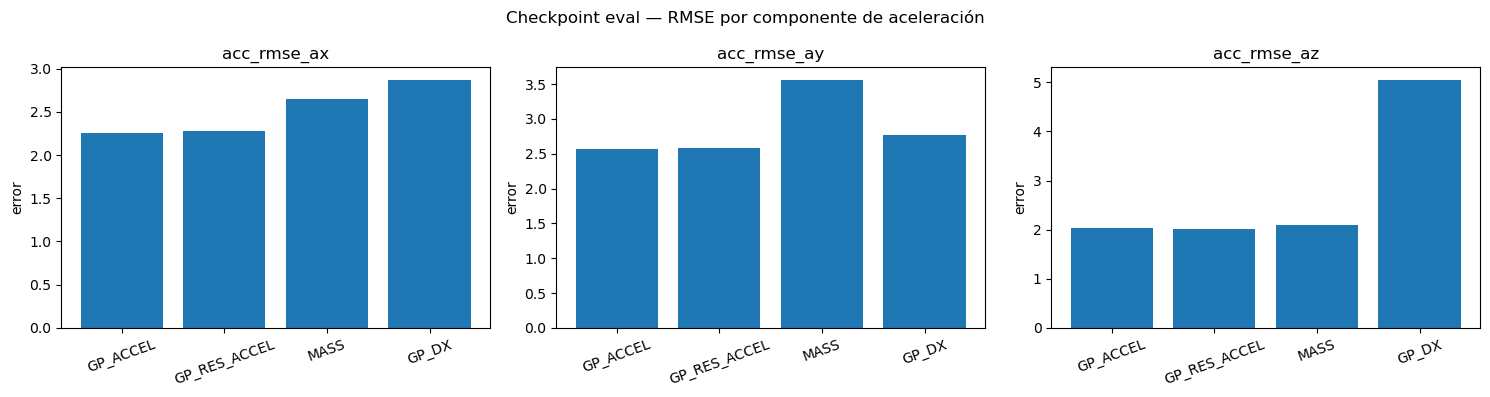

In [8]:

# Celda 5 — Gráficos resumen de checkpoints

if len(checkpoint_df):
    display(Markdown("### Métricas one-step"))
    display(checkpoint_df[["model"] + [c for c in metric_cols_for_ranking() if c in checkpoint_df.columns]].sort_values("next_state_rmse_mean"))

    plot_grouped_metric_bars(
        checkpoint_df.sort_values("next_state_rmse_mean"),
        metrics=[c for c in ["next_pos_rmse_mean", "next_vel_rmse_mean", "next_state_rmse_mean", "acc_rmse_mean"] if c in checkpoint_df.columns],
        title="Checkpoint eval — barras resumen"
    )

    plot_table_like_heatmap(
        leaderboard_df(checkpoint_df),
        title="Checkpoint eval — ranking por métricas"
    )

    plot_open_loop_curves(
        checkpoint_rollout_df,
        title="Checkpoint eval — error open-loop vs horizonte"
    )

    plot_metric_by_axis(
        checkpoint_df.sort_values("next_state_rmse_mean"),
        prefix="next_state_rmse",
        dims=DIM_STATE,
        title="Checkpoint eval — RMSE por componente de estado"
    )

    plot_metric_by_axis(
        checkpoint_df.sort_values("acc_rmse_mean"),
        prefix="acc_rmse",
        dims=DIM_ACC,
        title="Checkpoint eval — RMSE por componente de aceleración"
    )
else:
    print("No se ejecutó o no hubo resultados de checkpoint.")


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_pred_vs_true_estado_siguiente_-_gp_dx.png


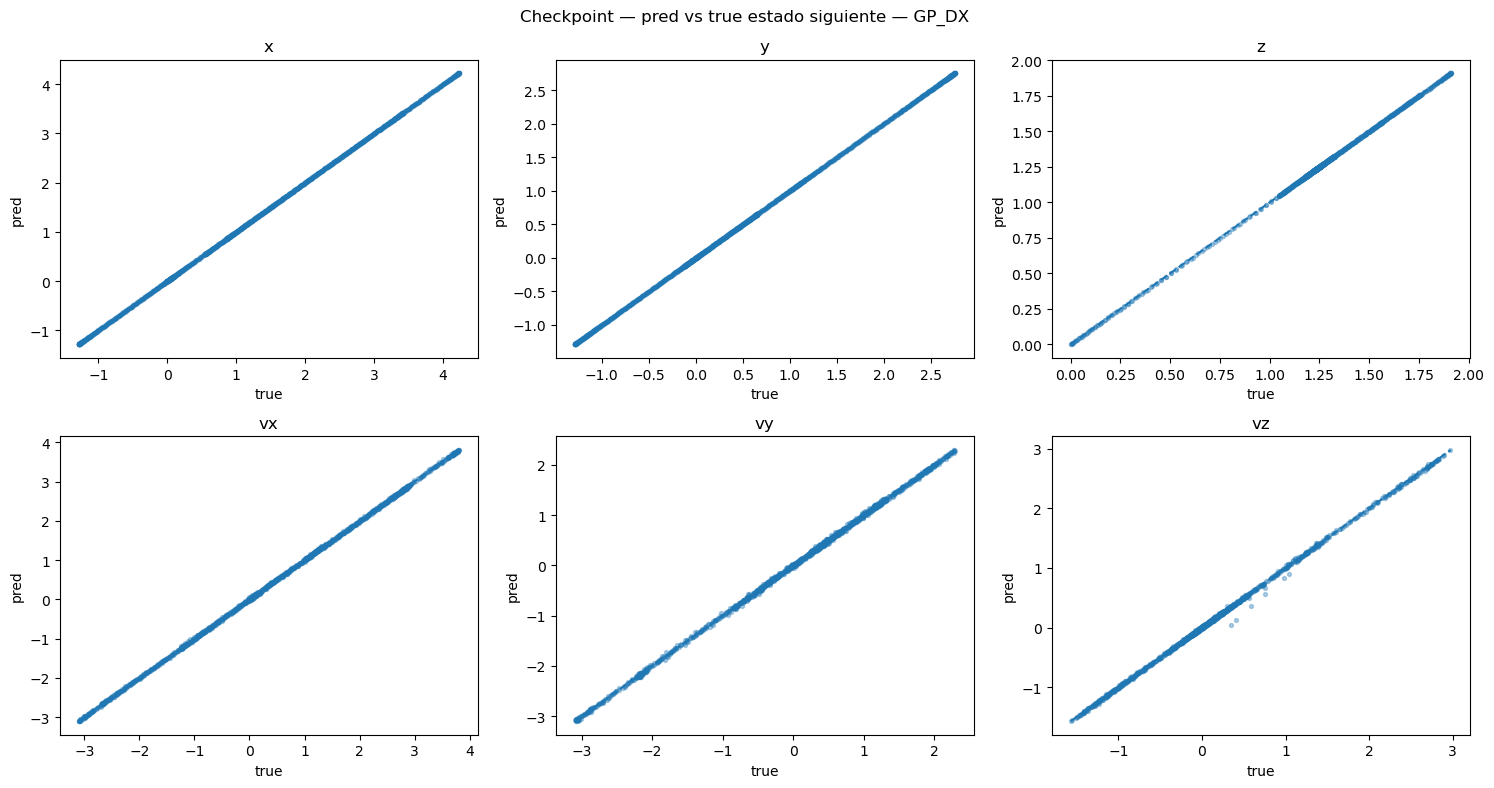

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_pred_vs_true_estado_siguiente_-_gp_accel.png


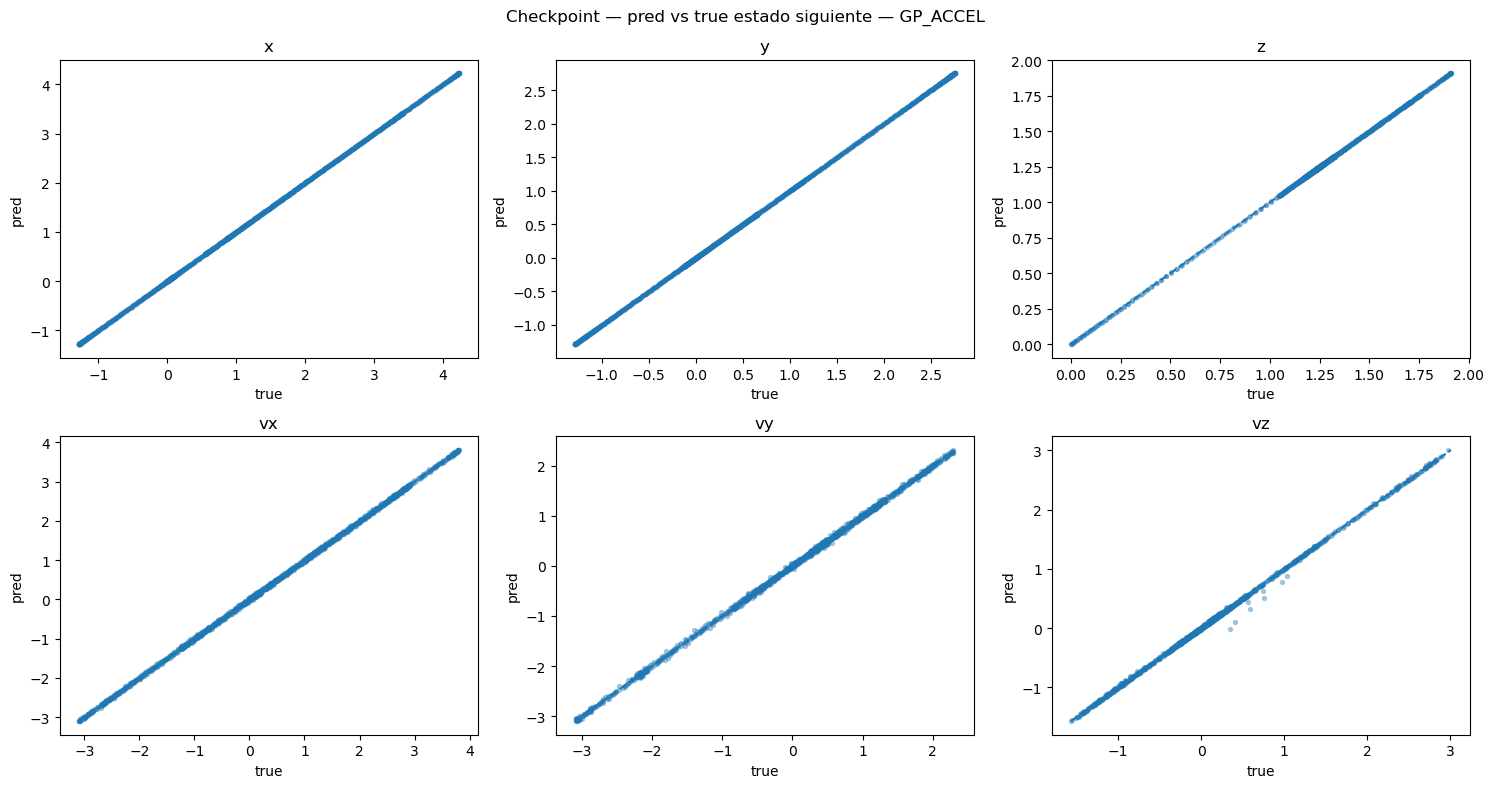

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_pred_vs_true_estado_siguiente_-_gp_res_accel.png


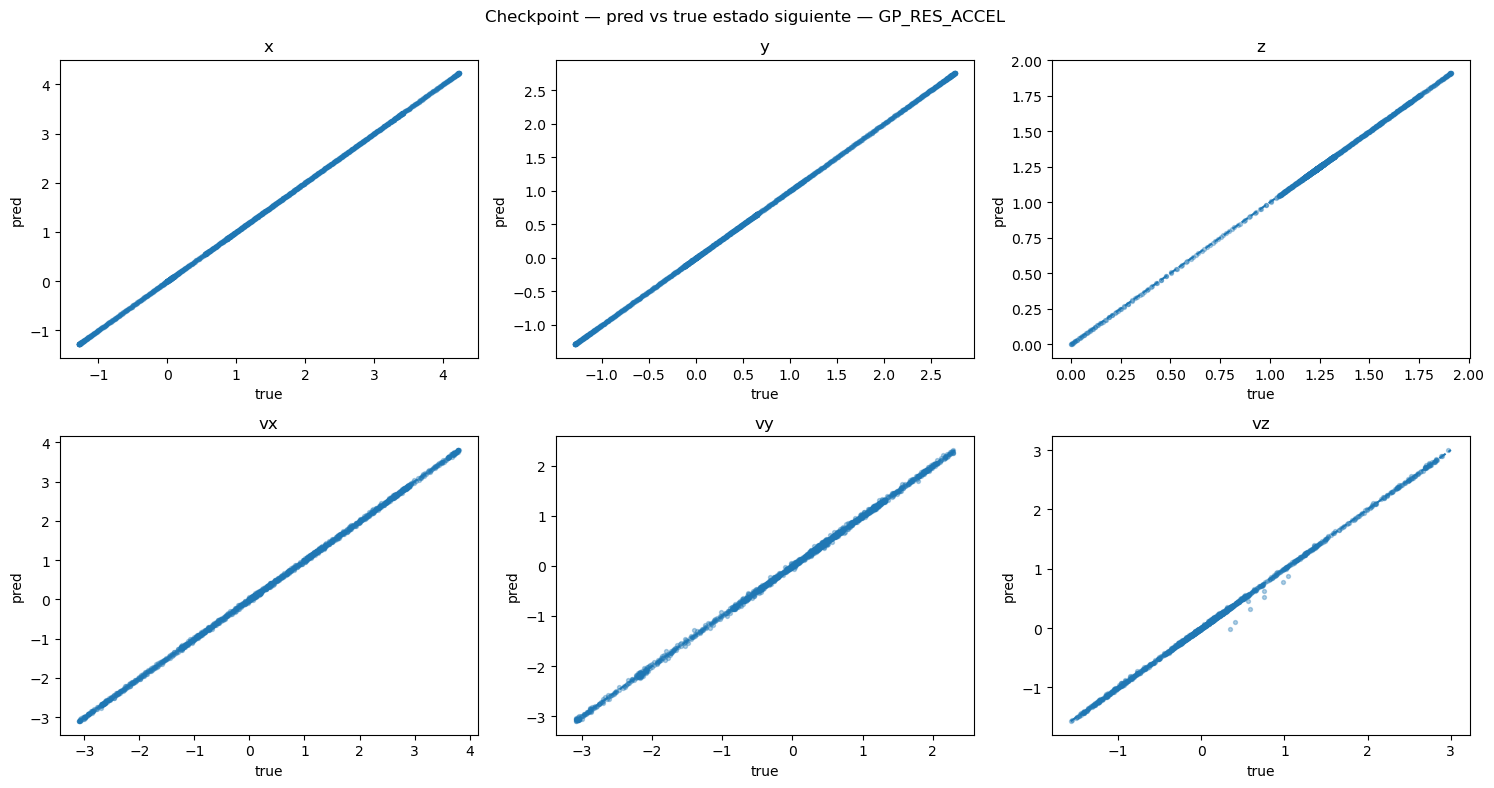

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_pred_vs_true_estado_siguiente_-_mass.png


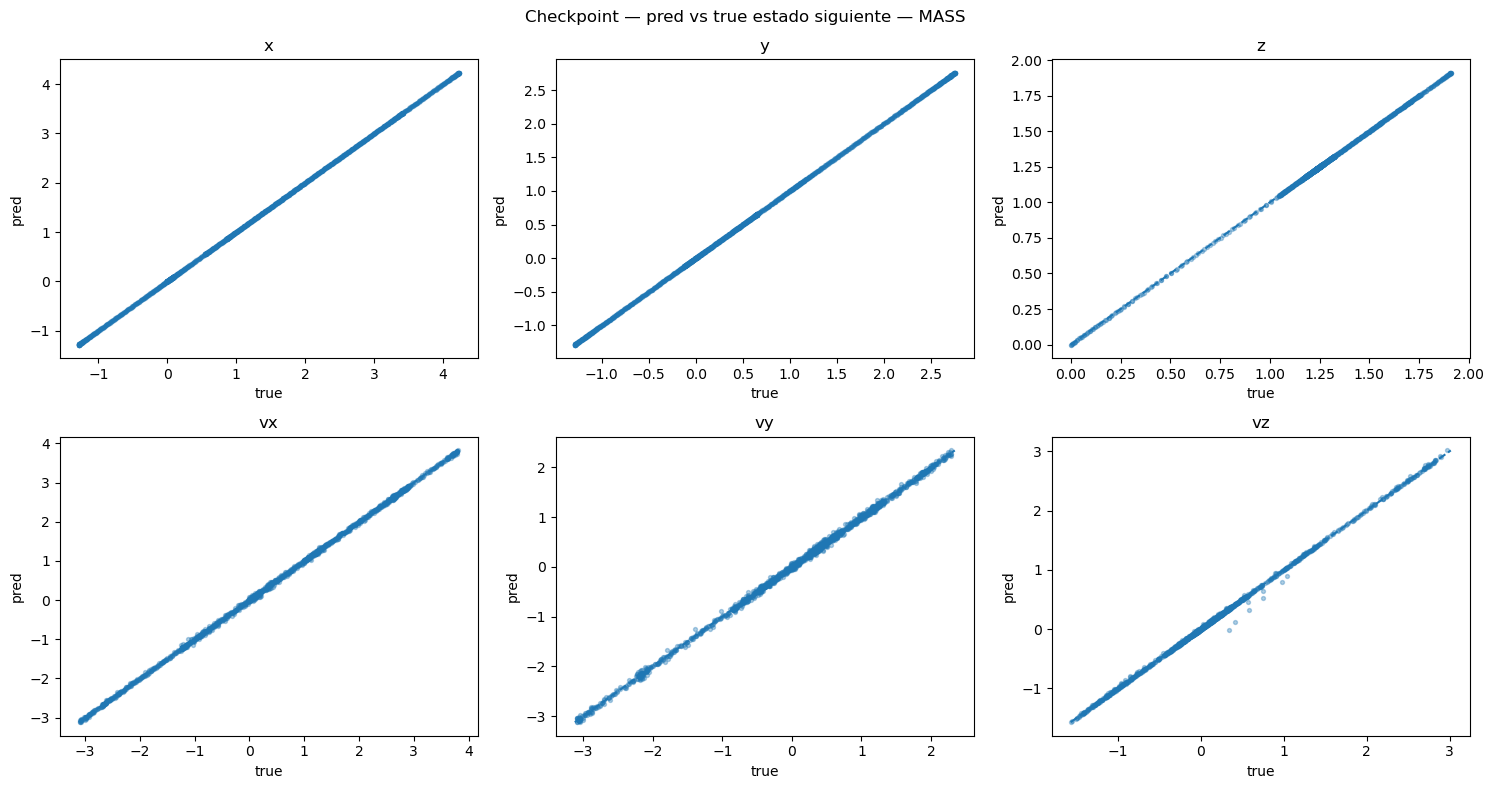

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_residuales_estado_siguiente_next_state.png


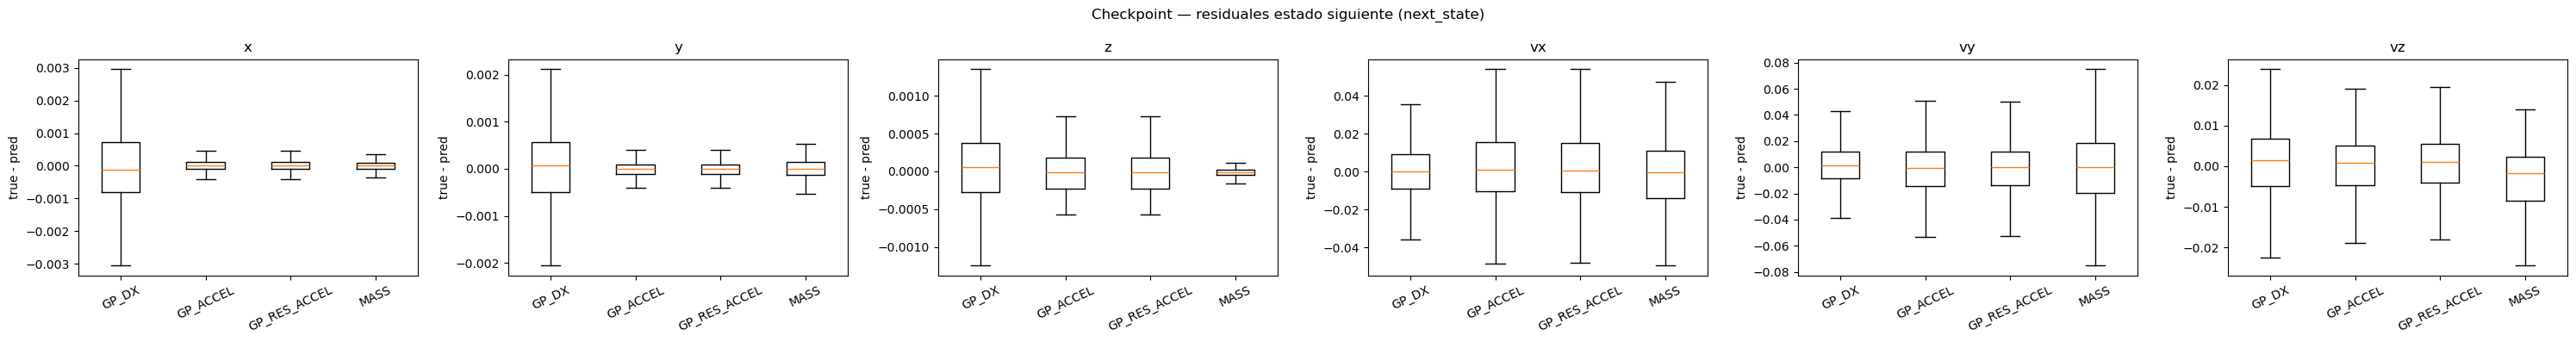

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_-_residuales_aceleración_acc.png


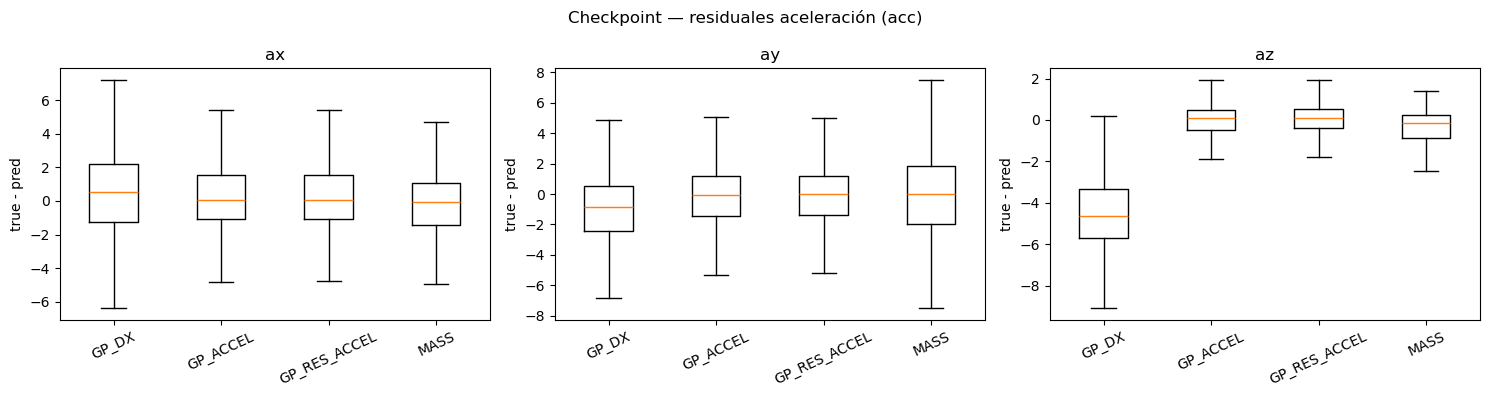

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\checkpoint_—_relación_fuerza_vs_aceleración_predicha.png


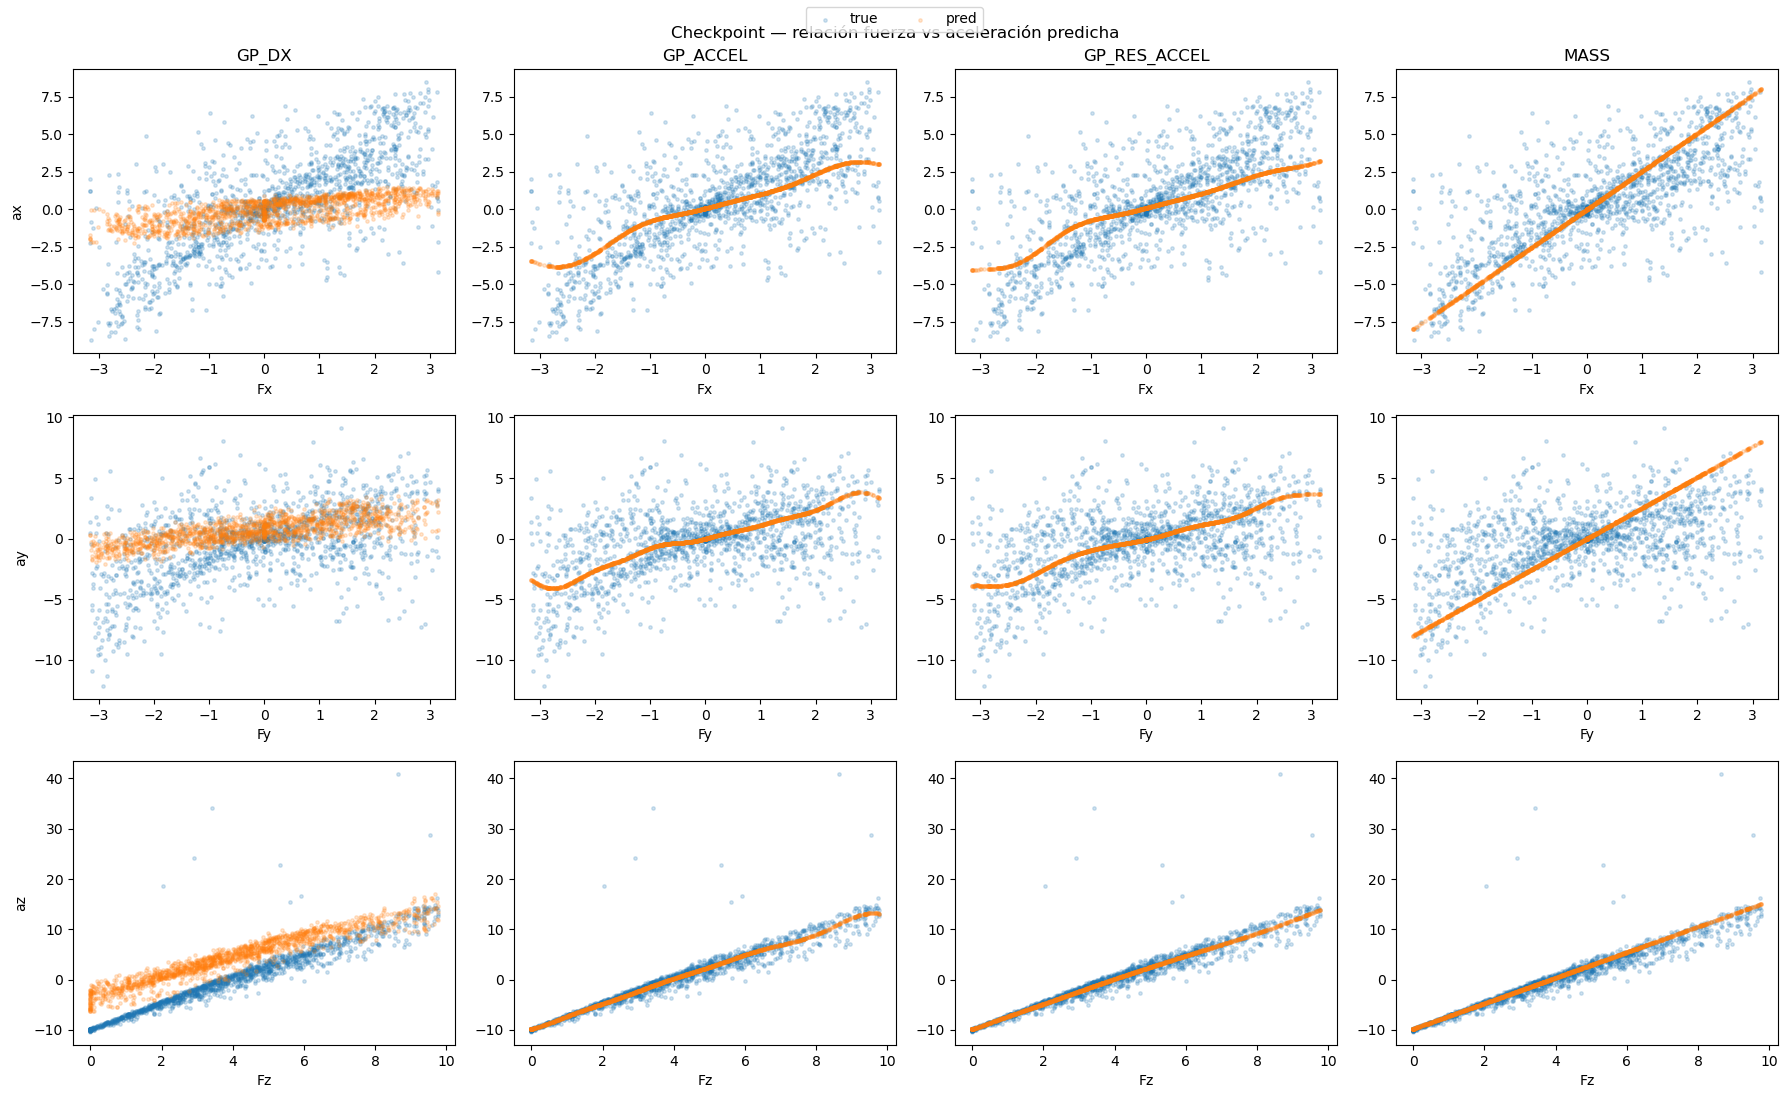

In [9]:

# Celda 6 — Gráficos detallados de checkpoints: pred vs true, residuales y F->a

if len(checkpoint_details):
    for model_name, pred in checkpoint_details.items():
        plot_pred_vs_true_grid(
            pred["X_next_true"], pred["X_next_pred"], DIM_STATE,
            title=f"Checkpoint — pred vs true estado siguiente — {model_name}",
            max_points=SCATTER_MAX_POINTS,
        )

    plot_residual_boxplots(
        checkpoint_details,
        kind="next_state",
        title="Checkpoint — residuales estado siguiente"
    )

    plot_residual_boxplots(
        checkpoint_details,
        kind="acc",
        title="Checkpoint — residuales aceleración"
    )

    plot_force_vs_acc(
        checkpoint_details,
        split.test,
        title="Checkpoint — relación fuerza vs aceleración predicha"
    )
else:
    print("No hay detalles de checkpoint.")


In [10]:

# Celda 7 — Reentrenamiento justo desde cero sobre el mismo split

retrain_models = {}
retrain_rows = []
retrain_rollout_rows = []
retrain_details = {}

if RUN_RETRAIN_EVAL:
    retrain_models = retrain_models_from_common_dx(split, checkpoint_paths, device=DEVICE)
    if INCLUDE_MASS:
        retrain_models["MASS"] = build_model_from_type(
            "MASS",
            dt=dt,
            mass=mass,
            gravity=gravity,
            device=DEVICE,
            dtype=torch.float32,
        )

    for model_name, model in retrain_models.items():
        out = evaluate_one_step_on_dx_dataset(model, model_name, split.test, device=DEVICE)
        retrain_rows.append({"model": model_name, **out["metrics"]})
        retrain_details[model_name] = out["pred"]

        rollout_rows = rollout_open_loop_final_error(
            model,
            model_name,
            split.test,
            horizons=HORIZONS,
            device=DEVICE,
            continuity_tol=CONTINUITY_TOL,
        )
        for rr in rollout_rows:
            retrain_rollout_rows.append({"model": model_name, **rr})

retrain_df = rows_to_df(retrain_rows)
retrain_rollout_df = rows_to_df(retrain_rollout_rows)

display(Markdown("## Retrain eval — leaderboard"))
display(leaderboard_df(retrain_df))


Full trained batched GP on 5600 points (out_dim=6).


## Retrain eval — leaderboard

,model,next_state_rmse_mean,next_pos_rmse_mean,next_vel_rmse_mean,acc_rmse_mean,rank_next_state_rmse_mean,rank_next_pos_rmse_mean,rank_next_vel_rmse_mean,rank_acc_rmse_mean,rank_mean
0,GP_DX,0.010585,0.001164,0.020006,3.739828,1.0,4.0,1.0,4.0,2.50
1,GP_ACCEL,0.011779,0.000218,0.023340,2.334034,2.0,2.0,2.0,1.0,1.75
2,GP_RES_ACCEL,0.011795,0.000218,0.023372,2.337216,3.0,2.0,3.0,2.0,2.50
3,MASS,0.013923,0.000170,0.027677,2.767662,4.0,1.0,4.0,3.0,3.00


### Métricas one-step

,model,next_state_rmse_mean,next_pos_rmse_mean,next_vel_rmse_mean,acc_rmse_mean
0,GP_DX,0.010585,0.001164,0.020006,3.739828
1,GP_ACCEL,0.011779,0.000218,0.023340,2.334034
2,GP_RES_ACCEL,0.011795,0.000218,0.023372,2.337216
3,MASS,0.013923,0.000170,0.027677,2.767662


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_eval_-_barras_resumen.png


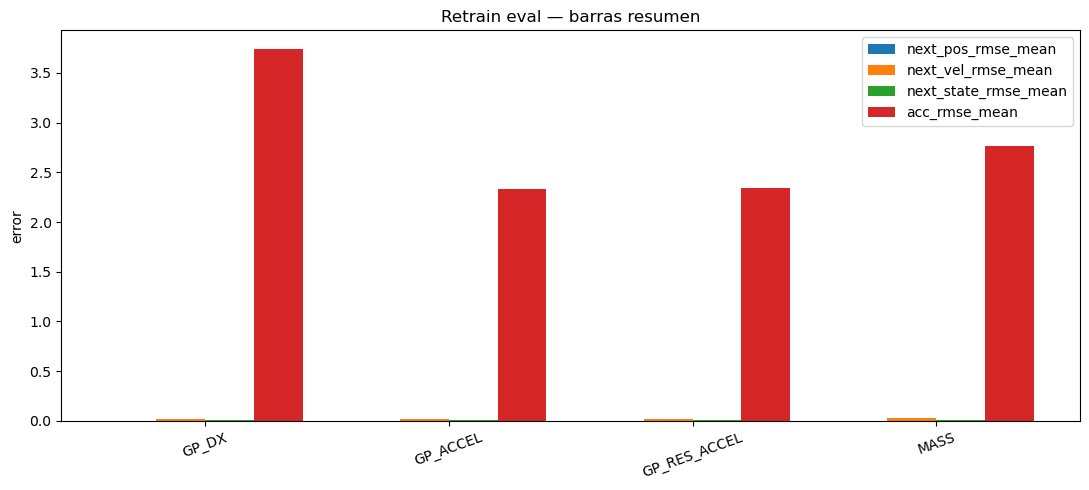

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_eval_-_ranking_por_métricas.png


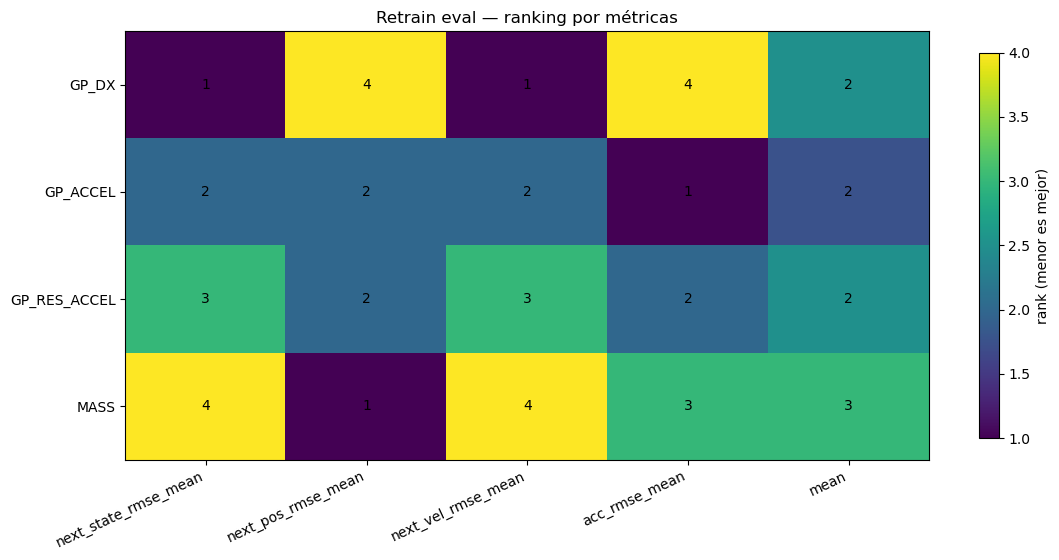

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_eval_-_error_open-loop_vs_horizonte.png


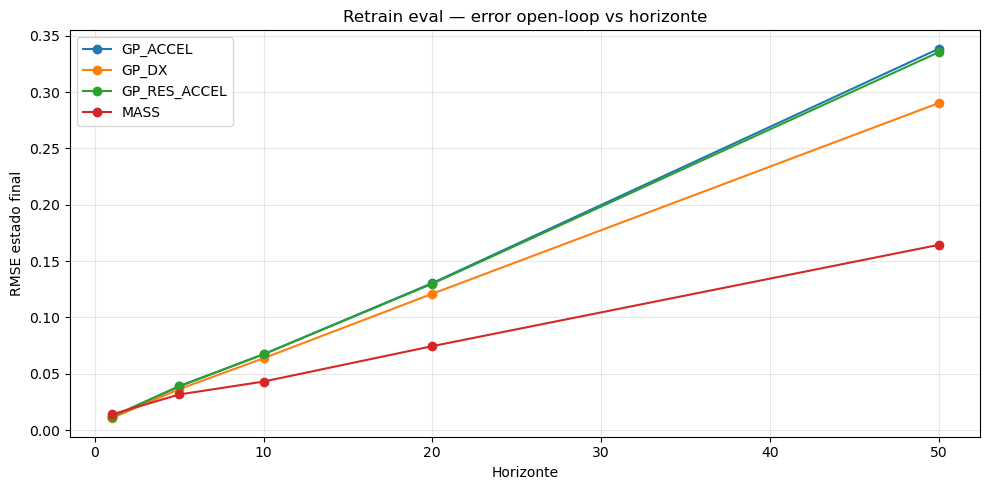

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_eval_-_rmse_por_componente_de_estado.png


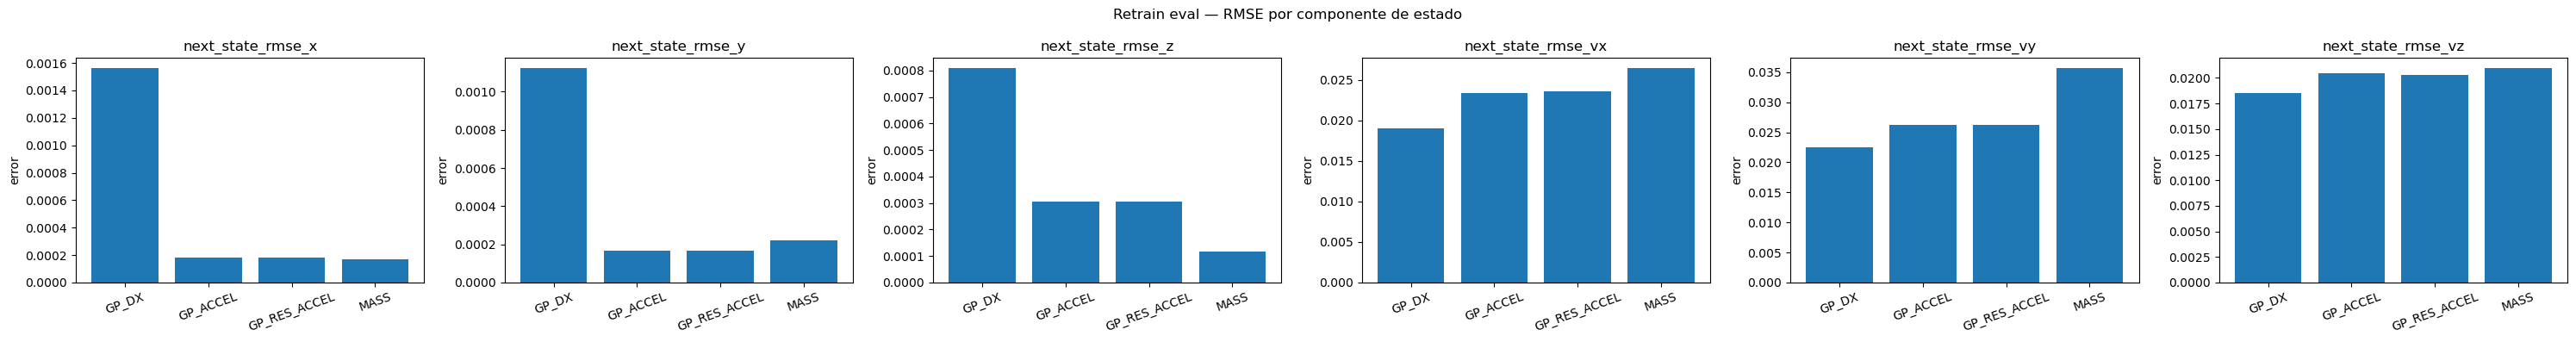

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_eval_-_rmse_por_componente_de_aceleración.png


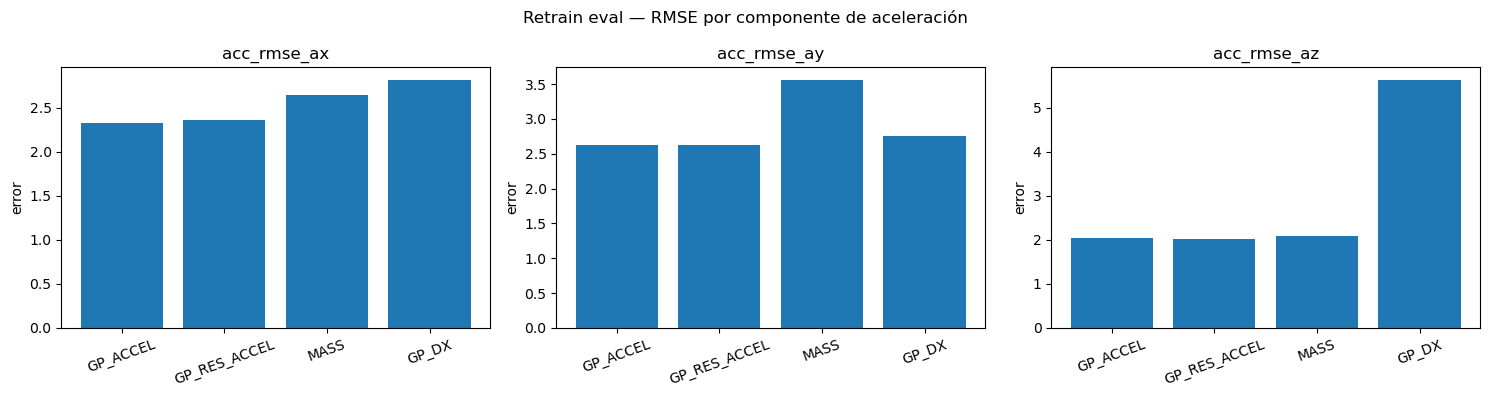

In [11]:

# Celda 8 — Gráficos resumen del reentrenamiento

if len(retrain_df):
    display(Markdown("### Métricas one-step"))
    display(retrain_df[["model"] + [c for c in metric_cols_for_ranking() if c in retrain_df.columns]].sort_values("next_state_rmse_mean"))

    plot_grouped_metric_bars(
        retrain_df.sort_values("next_state_rmse_mean"),
        metrics=[c for c in ["next_pos_rmse_mean", "next_vel_rmse_mean", "next_state_rmse_mean", "acc_rmse_mean"] if c in retrain_df.columns],
        title="Retrain eval — barras resumen"
    )

    plot_table_like_heatmap(
        leaderboard_df(retrain_df),
        title="Retrain eval — ranking por métricas"
    )

    plot_open_loop_curves(
        retrain_rollout_df,
        title="Retrain eval — error open-loop vs horizonte"
    )

    plot_metric_by_axis(
        retrain_df.sort_values("next_state_rmse_mean"),
        prefix="next_state_rmse",
        dims=DIM_STATE,
        title="Retrain eval — RMSE por componente de estado"
    )

    plot_metric_by_axis(
        retrain_df.sort_values("acc_rmse_mean"),
        prefix="acc_rmse",
        dims=DIM_ACC,
        title="Retrain eval — RMSE por componente de aceleración"
    )
else:
    print("No se ejecutó o no hubo resultados de retrain.")


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_pred_vs_true_estado_siguiente_-_gp_dx.png


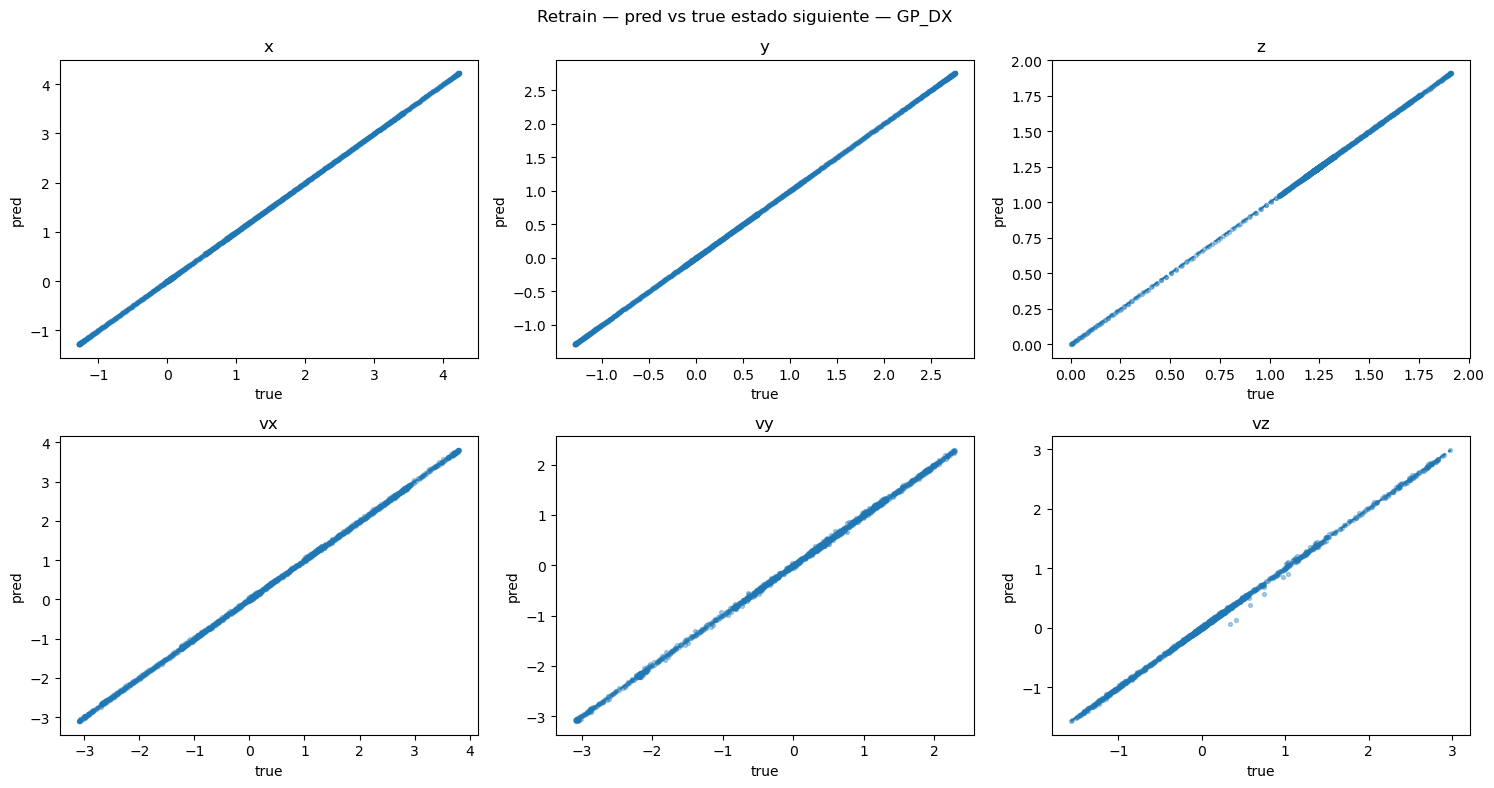

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_pred_vs_true_estado_siguiente_-_gp_accel.png


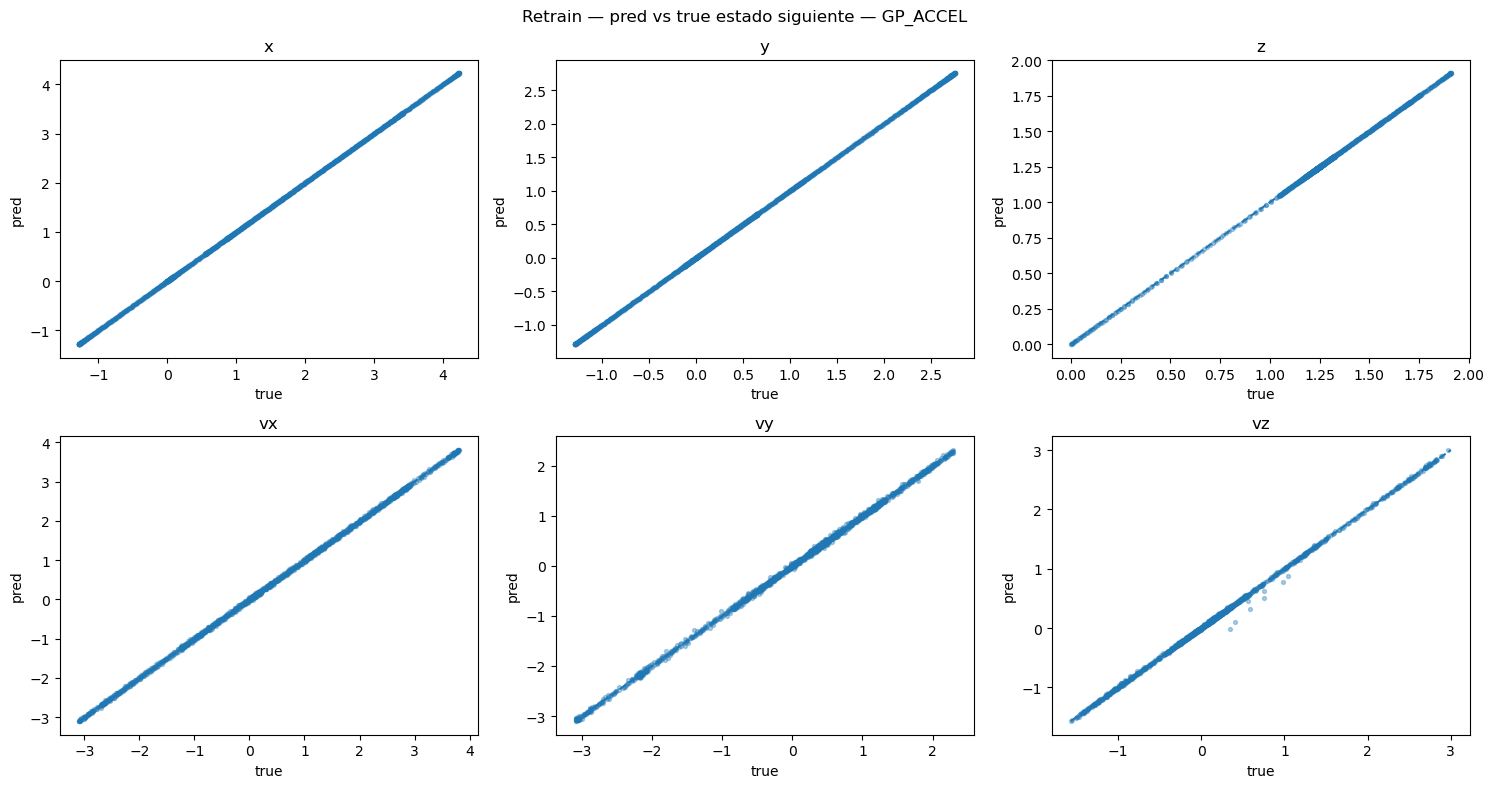

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_pred_vs_true_estado_siguiente_-_gp_res_accel.png


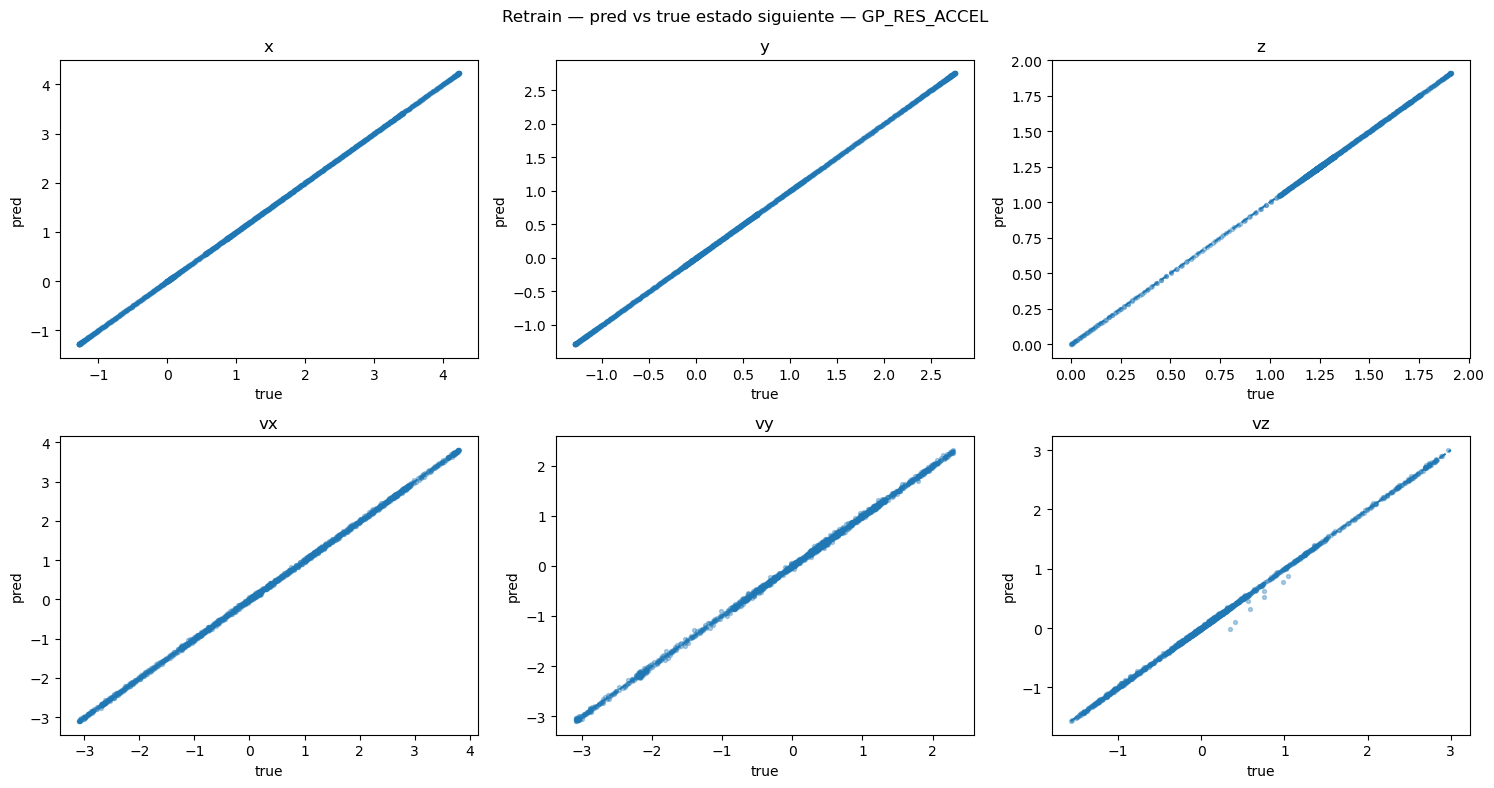

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_pred_vs_true_estado_siguiente_-_mass.png


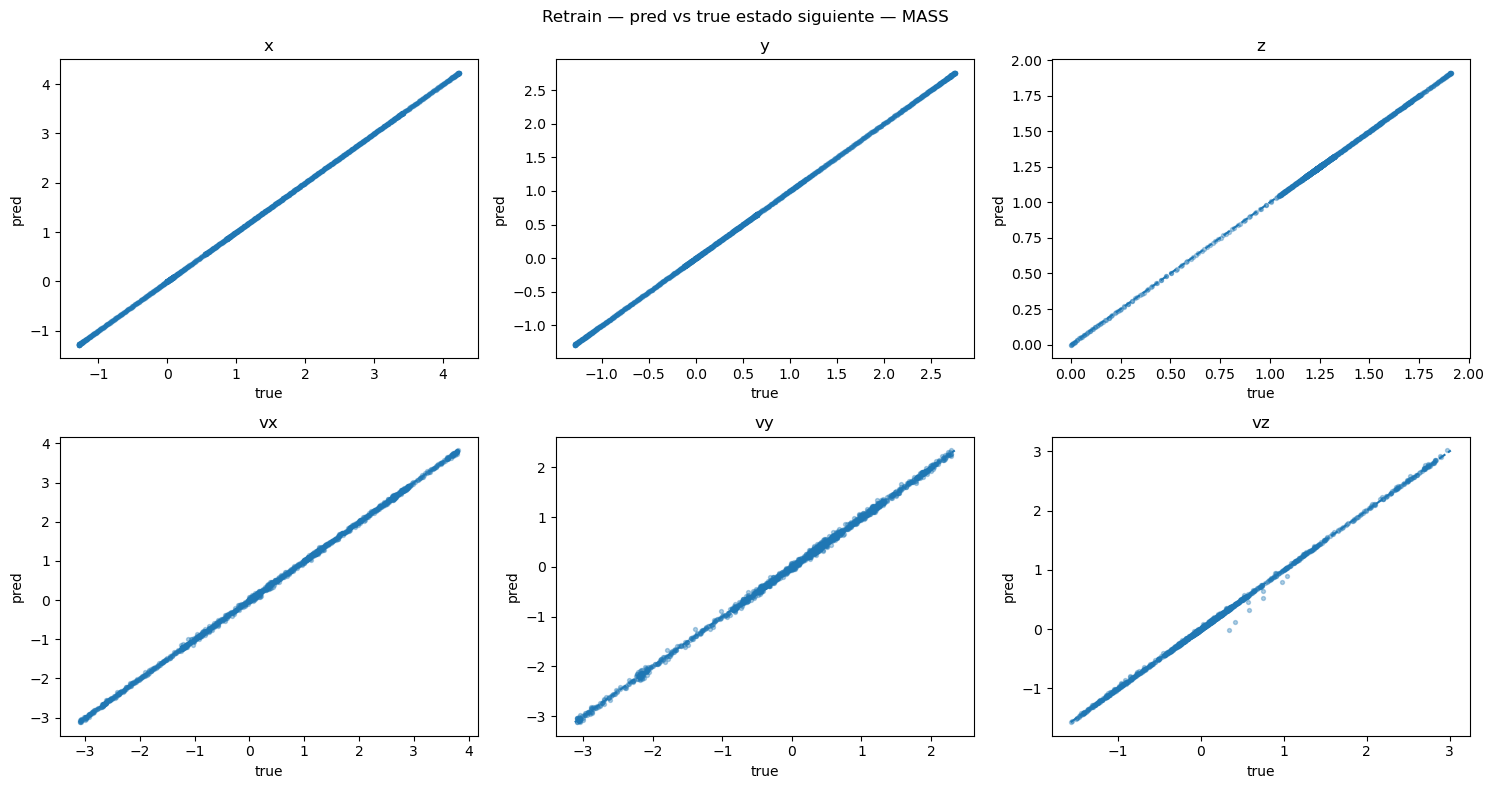

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_residuales_estado_siguiente_next_state.png


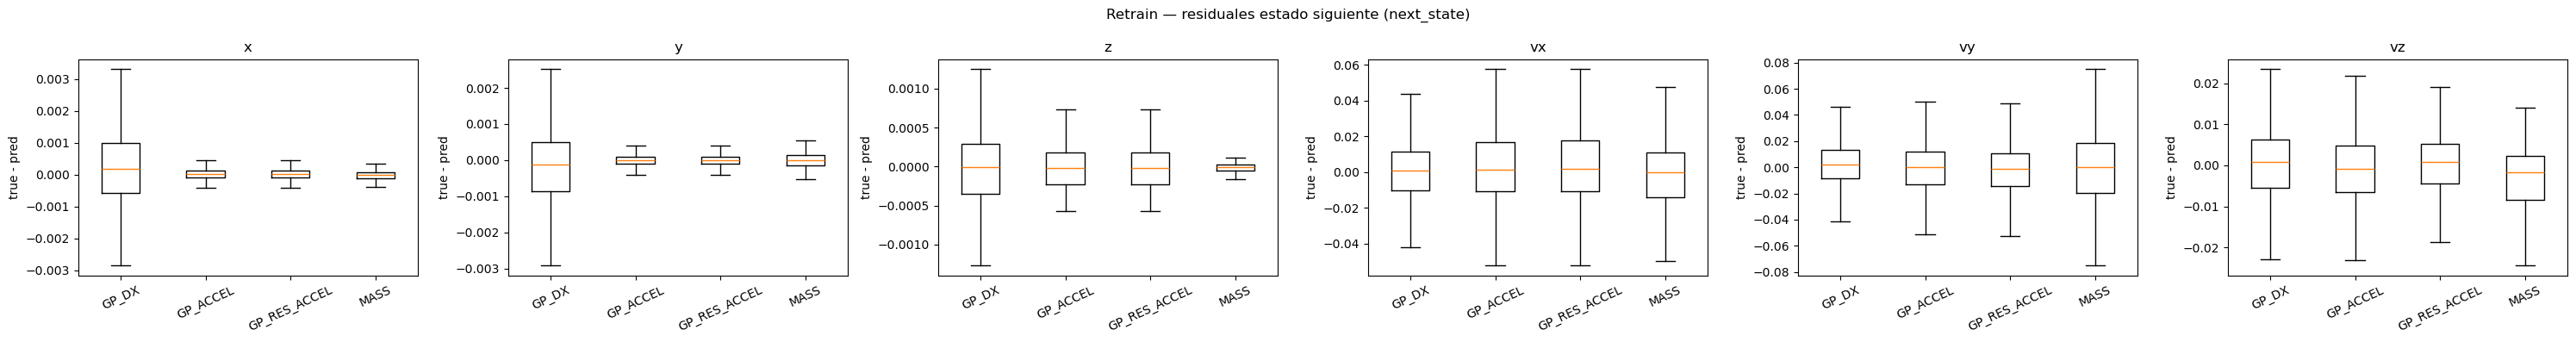

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_-_residuales_aceleración_acc.png


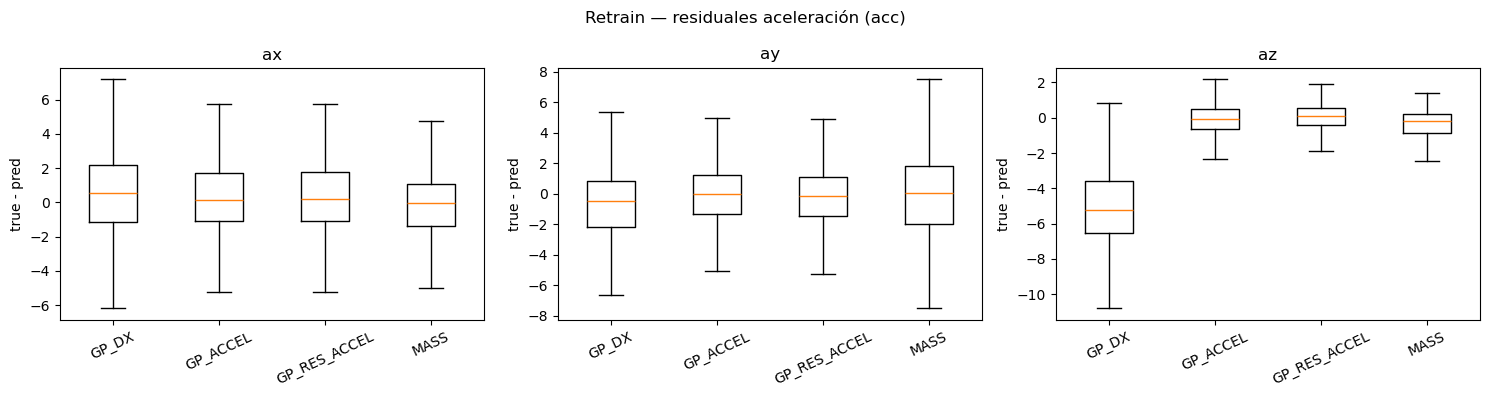

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\retrain_—_relación_fuerza_vs_aceleración_predicha.png


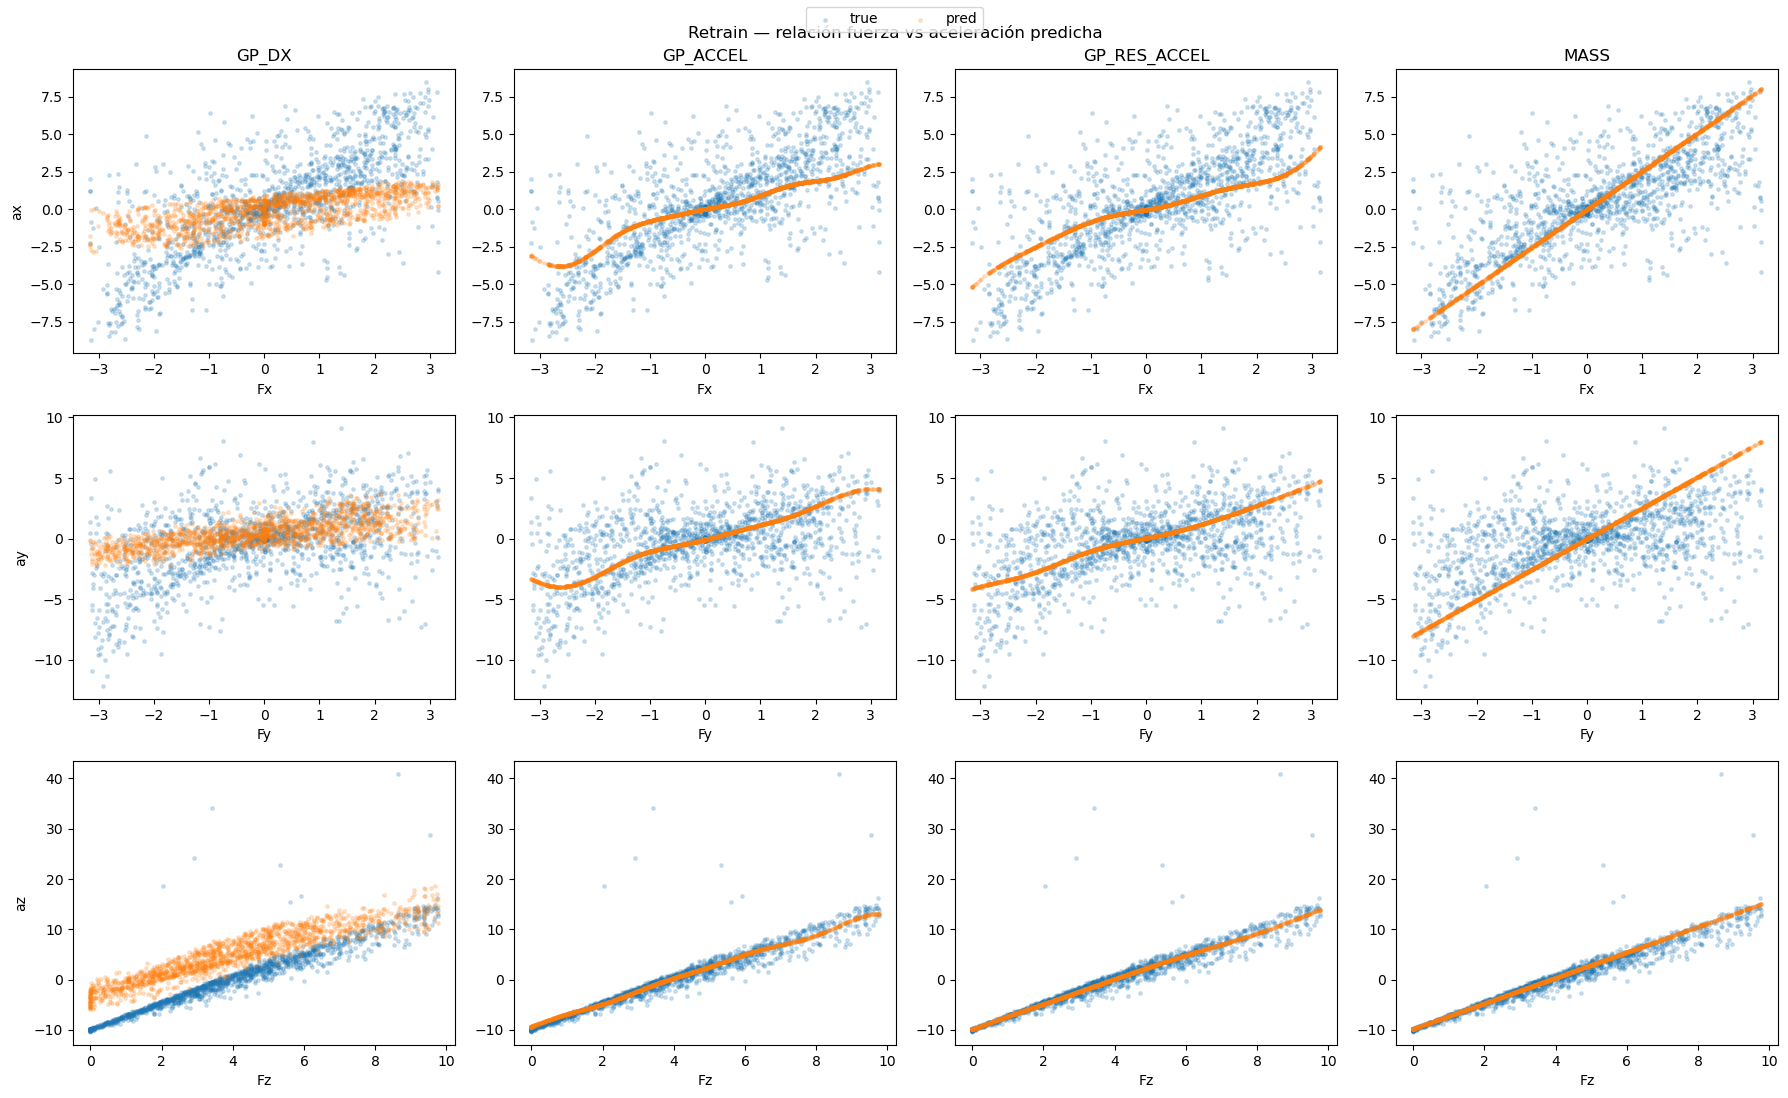

In [12]:

# Celda 9 — Gráficos detallados del reentrenamiento

if len(retrain_details):
    for model_name, pred in retrain_details.items():
        plot_pred_vs_true_grid(
            pred["X_next_true"], pred["X_next_pred"], DIM_STATE,
            title=f"Retrain — pred vs true estado siguiente — {model_name}",
            max_points=SCATTER_MAX_POINTS,
        )

    plot_residual_boxplots(
        retrain_details,
        kind="next_state",
        title="Retrain — residuales estado siguiente"
    )

    plot_residual_boxplots(
        retrain_details,
        kind="acc",
        title="Retrain — residuales aceleración"
    )

    plot_force_vs_acc(
        retrain_details,
        split.test,
        title="Retrain — relación fuerza vs aceleración predicha"
    )
else:
    print("No hay detalles de retrain.")


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\ejemplos_open_loop_checkpoint.png


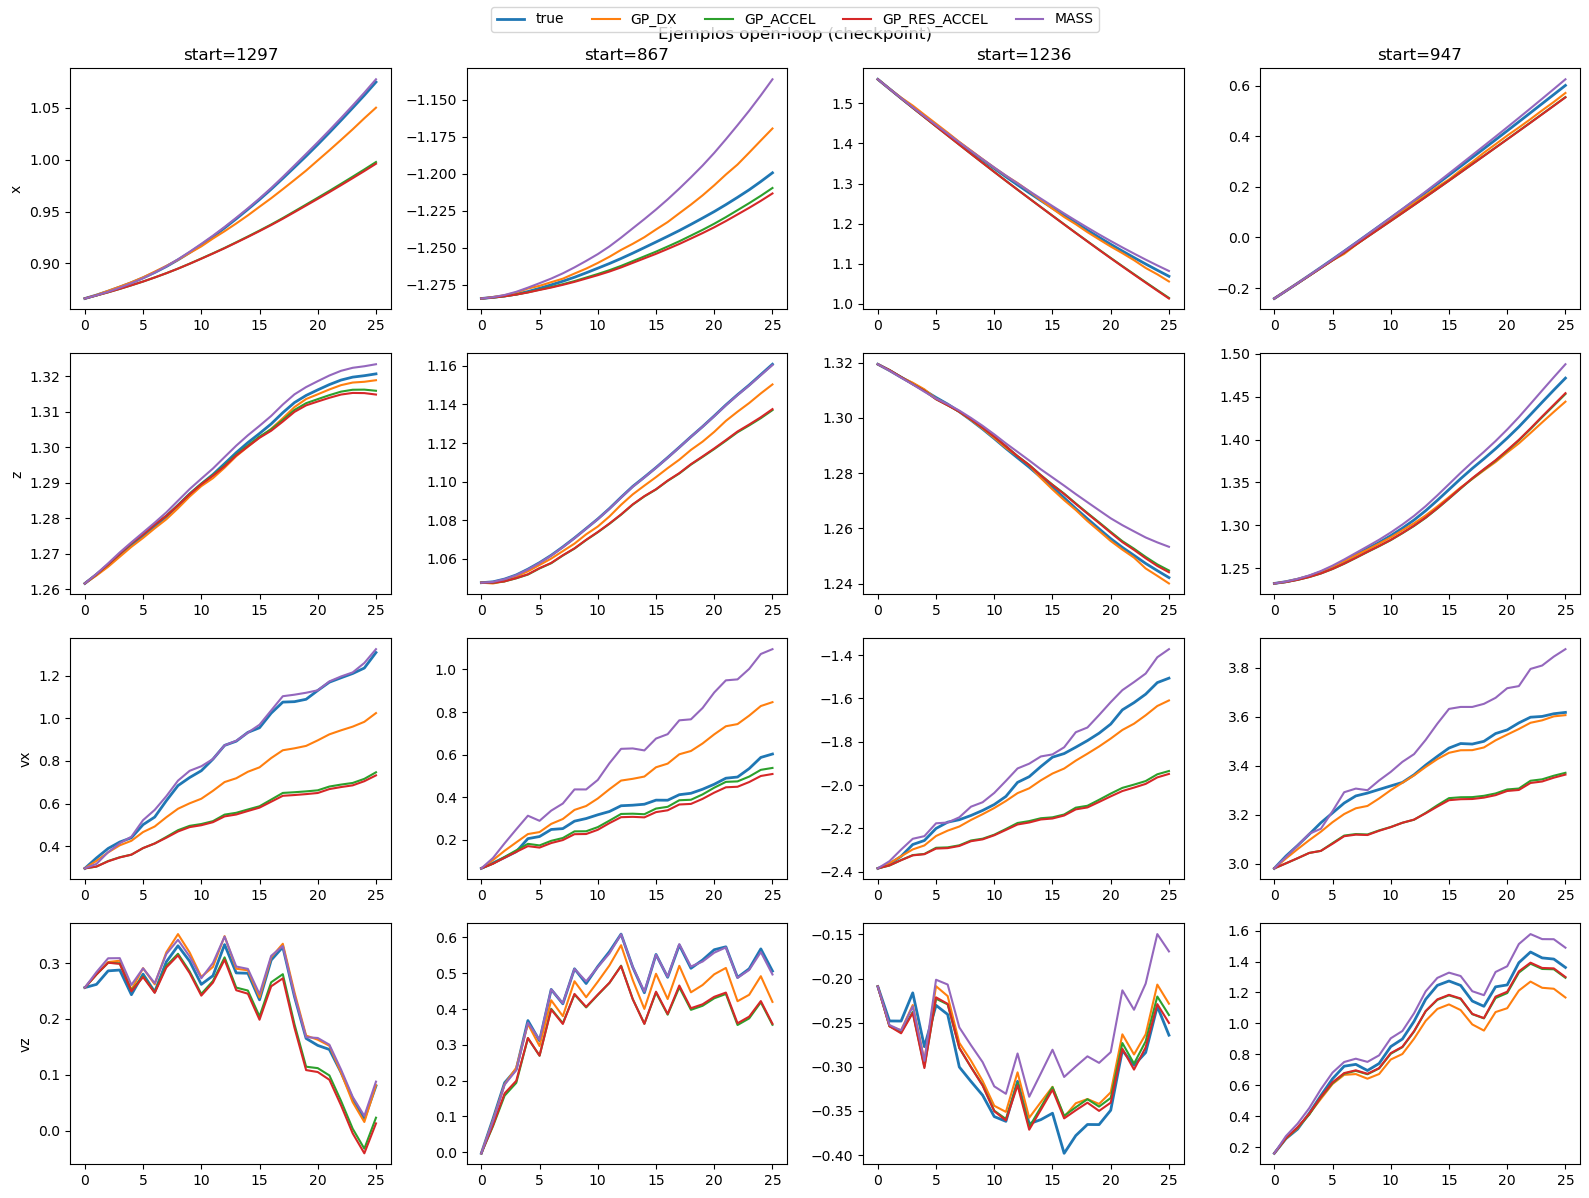

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\ejemplos_open_loop_retrain.png


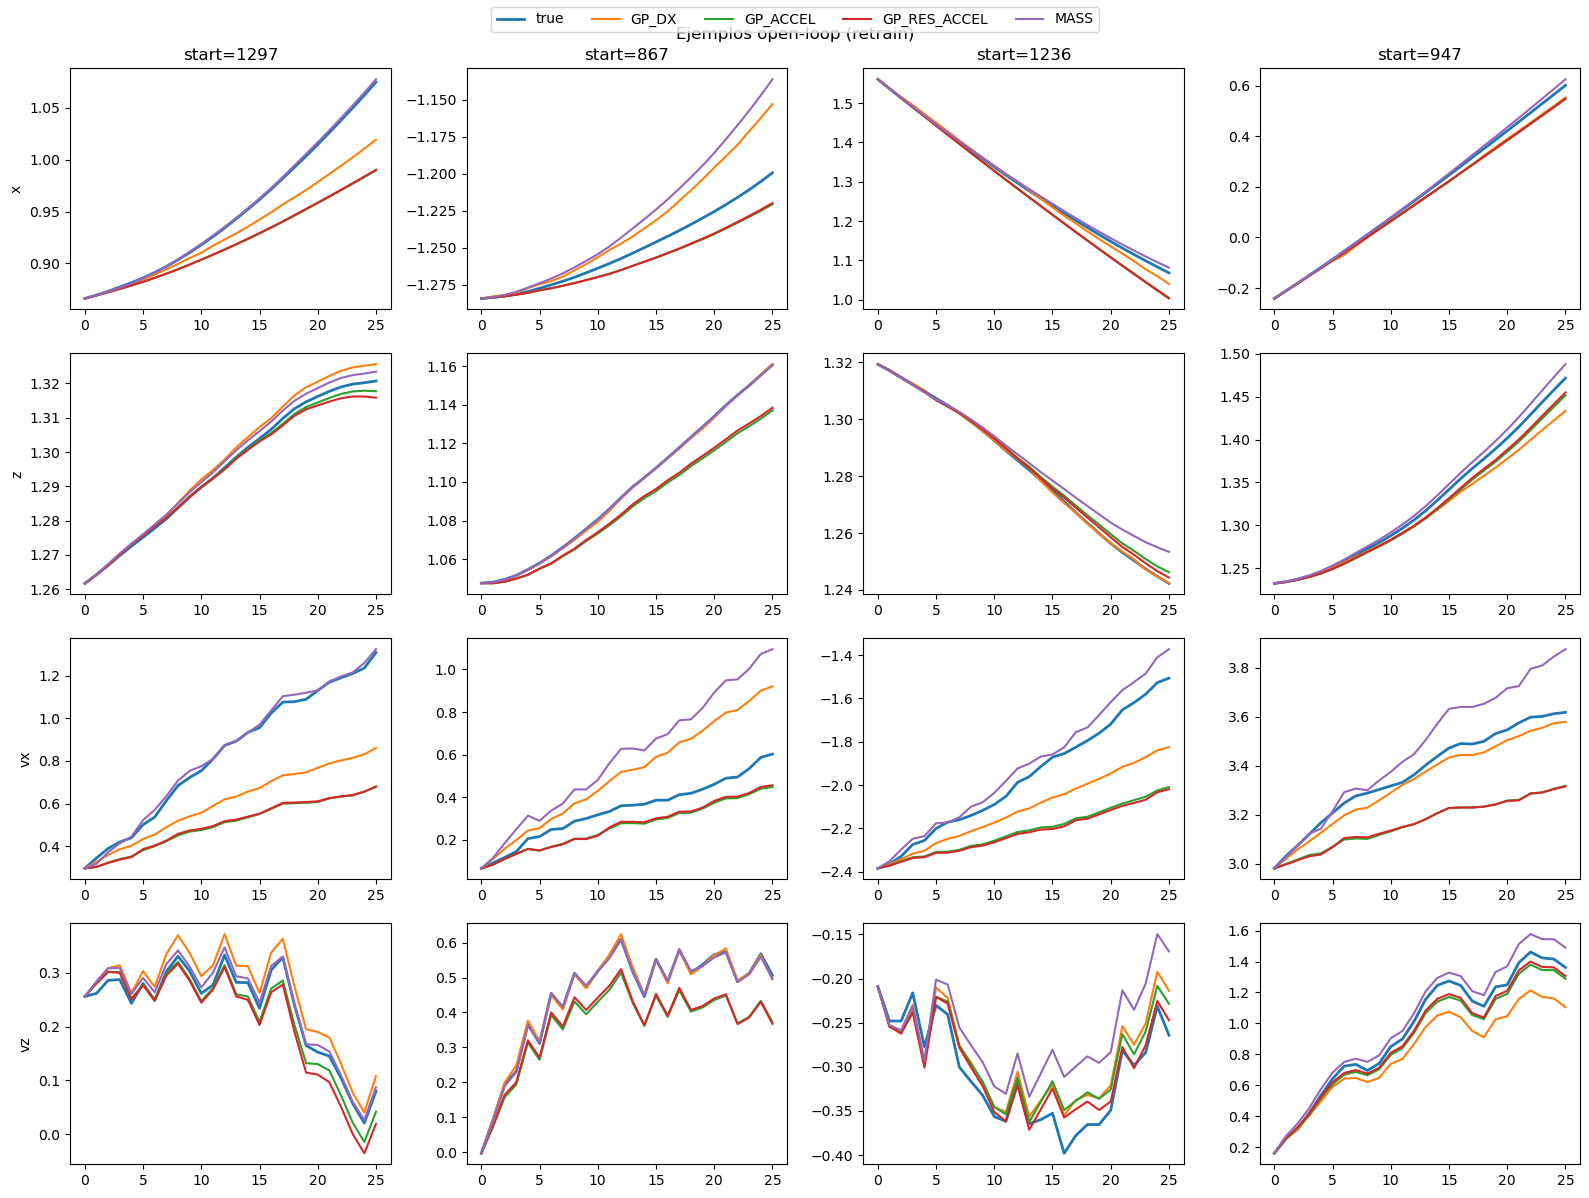

In [13]:

# Celda 10 — Ejemplos open-loop en ventanas reales (muy útil para MPPI)

if len(checkpoint_models):
    plot_rollout_examples(
        checkpoint_models,
        source_name="checkpoint",
        ds=split.test,
        horizon=ROLLOUT_EXAMPLE_HORIZON,
        n_examples=ROLLOUT_EXAMPLE_COUNT,
        components=ROLLOUT_COMPONENTS,
        tol=CONTINUITY_TOL,
    )

if len(retrain_models):
    plot_rollout_examples(
        retrain_models,
        source_name="retrain",
        ds=split.test,
        horizon=ROLLOUT_EXAMPLE_HORIZON,
        n_examples=ROLLOUT_EXAMPLE_COUNT,
        components=ROLLOUT_COMPONENTS,
        tol=CONTINUITY_TOL,
    )


In [18]:

# Celda 11 — Curvas de aprendizaje (opcional, más lento)
# Entrena desde cero cada arquitectura con distintos tamaños de train.
# Esto sirve para ver cuál aprende más rápido y cuál escala mejor.

def run_learning_curves(split, checkpoint_paths, sizes, device):
    sizes = sorted(set([s for s in sizes if 0 < s <= split.train.Z.shape[0]]))
    results = []

    for model_type in ["GP_DX", "GP_ACCEL", "GP_RES_ACCEL"]:
        cfg = cfg_from_checkpoint_if_available(model_type, checkpoint_paths)
        for s in sizes:
            model = build_trainable_model(
                model_type=model_type,
                ds=split.train,
                device=device,
                dtype=torch.float32,
                cfg=cfg,
            )

            # recortar subset del train
            sub_train = temporal_split_dx(
                load_dx_rollouts(eval_rollouts_path, dt=dt, mass=mass, gravity=gravity),
                test_frac=TEST_FRAC
            ).train
            sub_train = type(sub_train)(
                Z=sub_train.Z[:s],
                dX=sub_train.dX[:s],
                dt=sub_train.dt,
                mass=sub_train.mass,
                gravity=sub_train.gravity,
            )

            preload_train_split_into_model(model, model_type, sub_train)
            model.train_full()

            out = evaluate_one_step_on_dx_dataset(model, model_type, split.test, device=device)
            results.append({
                "model": model_type,
                "train_size": s,
                "next_state_rmse_mean": out["metrics"]["next_state_rmse_mean"],
                "acc_rmse_mean": out["metrics"]["acc_rmse_mean"],
            })

    return pd.DataFrame(results)

learning_curve_df = pd.DataFrame()
if RUN_LEARNING_CURVES:
    learning_curve_df = run_learning_curves(split, checkpoint_paths, LC_SIZES, LC_DEVICE)
    display(learning_curve_df.head())


Full trained batched GP on 300 points (out_dim=6).
Full trained batched GP on 800 points (out_dim=6).
Full trained batched GP on 1500 points (out_dim=6).
Full trained batched GP on 3000 points (out_dim=6).


,model,train_size,next_state_rmse_mean,acc_rmse_mean
0,GP_DX,300,0.026798,4.361008
1,GP_DX,800,0.015796,3.452103
2,GP_DX,1500,0.012722,3.541956
3,GP_DX,3000,0.011826,3.979451
4,GP_ACCEL,300,0.013141,2.606506


Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\learning_curve_next_state.png


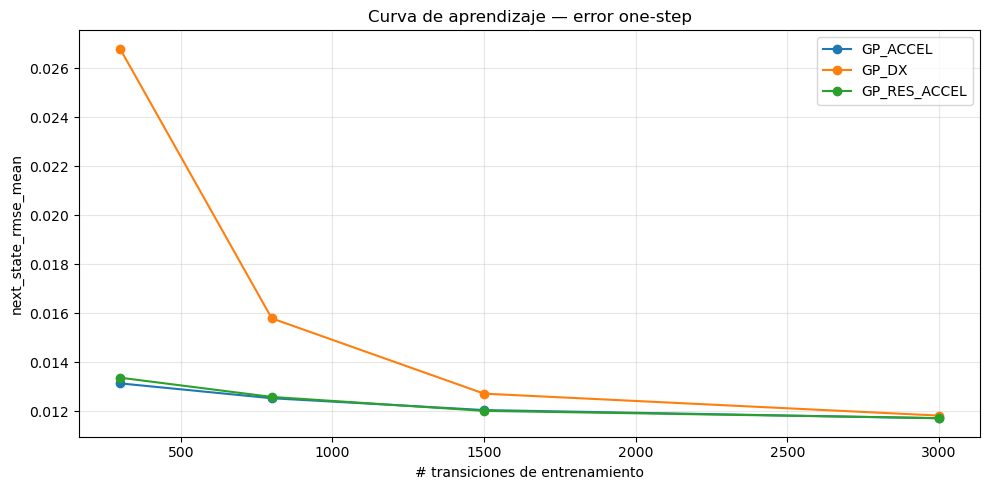

Guardado: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook\learning_curve_acc.png


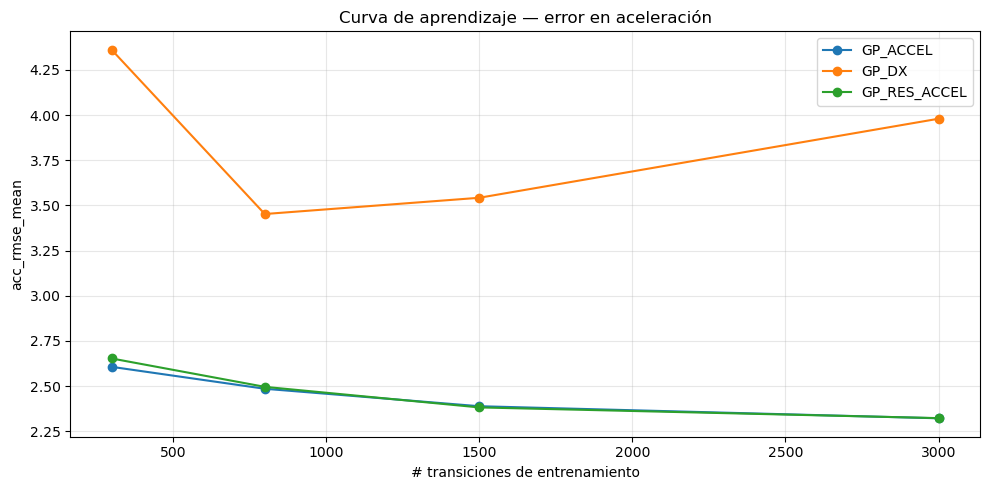

In [19]:

# Celda 12 — Gráficas de curvas de aprendizaje

if RUN_LEARNING_CURVES and len(learning_curve_df):
    fig = plt.figure(figsize=(10, 5))
    for model_name in sorted(learning_curve_df["model"].unique()):
        sub = learning_curve_df[learning_curve_df["model"] == model_name].sort_values("train_size")
        plt.plot(sub["train_size"], sub["next_state_rmse_mean"], marker="o", label=model_name)
    plt.xlabel("# transiciones de entrenamiento")
    plt.ylabel("next_state_rmse_mean")
    plt.title("Curva de aprendizaje — error one-step")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("learning_curve_next_state.png")
    plt.show()

    fig = plt.figure(figsize=(10, 5))
    for model_name in sorted(learning_curve_df["model"].unique()):
        sub = learning_curve_df[learning_curve_df["model"] == model_name].sort_values("train_size")
        plt.plot(sub["train_size"], sub["acc_rmse_mean"], marker="o", label=model_name)
    plt.xlabel("# transiciones de entrenamiento")
    plt.ylabel("acc_rmse_mean")
    plt.title("Curva de aprendizaje — error en aceleración")
    plt.grid(True, alpha=0.3)
    plt.legend()
    savefig("learning_curve_acc.png")
    plt.show()
else:
    print("RUN_LEARNING_CURVES=False o no hay resultados.")


In [21]:

# Celda 13 — Guardar tablas CSV y resumen final

if len(checkpoint_df):
    checkpoint_df.to_csv(os.path.join(OUT_DIR, "checkpoint_metrics.csv"), index=False)
if len(checkpoint_rollout_df):
    checkpoint_rollout_df.to_csv(os.path.join(OUT_DIR, "checkpoint_rollout.csv"), index=False)
if len(retrain_df):
    retrain_df.to_csv(os.path.join(OUT_DIR, "retrain_metrics.csv"), index=False)
if len(retrain_rollout_df):
    retrain_rollout_df.to_csv(os.path.join(OUT_DIR, "retrain_rollout.csv"), index=False)
if RUN_LEARNING_CURVES and len(learning_curve_df):
    learning_curve_df.to_csv(os.path.join(OUT_DIR, "learning_curves.csv"), index=False)

display(Markdown("## Conclusión rápida"))
if len(retrain_df):
    lb = leaderboard_df(retrain_df)
    display(lb)
    best = lb.iloc[0]["model"]
    print(f"Mejor modelo según retrain + next_state_rmse_mean: {best}")
elif len(checkpoint_df):
    lb = leaderboard_df(checkpoint_df)
    display(lb)
    best = lb.iloc[0]["model"]
    print(f"Mejor modelo según checkpoint + next_state_rmse_mean: {best}")
else:
    print("No hay resultados todavía.")

print("\nTodos los artefactos del notebook quedaron en:", OUT_DIR)


## Conclusión rápida

,model,next_state_rmse_mean,next_pos_rmse_mean,next_vel_rmse_mean,acc_rmse_mean,rank_next_state_rmse_mean,rank_next_pos_rmse_mean,rank_next_vel_rmse_mean,rank_acc_rmse_mean,rank_mean
0,GP_DX,0.010585,0.001164,0.020006,3.739828,1.0,4.0,1.0,4.0,2.50
1,GP_ACCEL,0.011779,0.000218,0.023340,2.334034,2.0,2.0,2.0,1.0,1.75
2,GP_RES_ACCEL,0.011795,0.000218,0.023372,2.337216,3.0,2.0,3.0,2.0,2.50
3,MASS,0.013923,0.000170,0.027677,2.767662,4.0,1.0,4.0,3.0,3.00


Mejor modelo según retrain + next_state_rmse_mean: GP_DX

Todos los artefactos del notebook quedaron en: d:\Lehigh\1st Semester\Indepedent Study\Code\RL-Rod-Project\model_based_v2\logs\evaluation_learning_notebook
